Original Dataset (later changed)

In [1]:
import pandas as pd  
import os           

# A dictionary used to map ID codes to city names
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def filter_weather_stations(input_dir, output_dir):
    
    # Check if the input folder exists in the current directory
    if not os.path.exists(input_dir):
        # If not, look one level up (../normals-daily)
        parent_path = os.path.join('..', input_dir)
        if os.path.exists(parent_path):
            input_dir = parent_path
        else:
            # If neither exist, exit and tell the user where the script is looking
            print(f"Error: Could not find '{input_dir}' in current or parent folder.")
            print(f"Current working directory is: {os.getcwd()}")
            return

    # Create the output folder if it's missing
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Look at every file inside the input folder
    for filename in os.listdir(input_dir):
        # Only open files ending in .csv
        if filename.endswith('.csv'):
            file_path = os.path.join(input_dir, filename)
            
            try:
                # Load CSV into memory; low_memory=False handles columns with mixed data types
                df = pd.read_csv(file_path, low_memory=False)
                
                # Verify the expected 'STATION' column is present
                if 'STATION' in df.columns:
                    # Clean the station IDs (convert to string and remove whitespace)
                    df['STATION'] = df['STATION'].astype(str).str.strip()
                    
                    # Filter: Keep only the rows where the STATION is in our dictionary keys
                    relevant_data = df[df['STATION'].isin(STATION_MAP.keys())]

                    # Group the filtered results by Station ID to save them individually
                    for station_id, group in relevant_data.groupby('STATION'):
                        # Look up the human-readable name (e.g., 'NYC_CentralPark')
                        out_name = f"{STATION_MAP[station_id]}.csv"
                        out_path = os.path.join(output_dir, out_name)
                        
                        # Logic to avoid writing headers multiple times if appending to a file
                        header = not os.path.exists(out_path)
                        
                        # Save the group to its specific CSV file
                        # mode='a' means 'append'—it adds to the file instead of overwriting it
                        group.to_csv(out_path, mode='a', index=False, header=header)
                        print(f"Success: Added data to {out_name}")
                        
            except Exception as e:
                # Catch issues like permission errors or corrupted CSVs
                print(f"Failed to process {filename}: {e}")

# Trigger the function with your specific folder names
filter_weather_stations('normals-daily', 'extracted_stations')

Success: Added data to EastStroudsburg_PA.csv
Success: Added data to Philly_PA.csv
Success: Added data to Newark_NJ.csv
Success: Added data to Allentown_PA.csv
Success: Added data to Bridgeport_CT.csv
Success: Added data to Scranton_PA.csv
Success: Added data to NYC_CentralPark.csv
Success: Added data to NYC_JFK_Airport.csv


--- Loading and Cleaning data from extracted_stations ---


C:\Users\harol\AppData\Local\Temp\ipykernel_33360\54046911.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')


Successfully loaded: Allentown_PA.csv


C:\Users\harol\AppData\Local\Temp\ipykernel_33360\54046911.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')


Successfully loaded: Bridgeport_CT.csv


...

Successfully loaded: NYC_JFK_Airport.csv


C:\Users\harol\AppData\Local\Temp\ipykernel_33360\54046911.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')


Successfully loaded: Philly_PA.csv


C:\Users\harol\AppData\Local\Temp\ipykernel_33360\54046911.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')


Successfully loaded: Scranton_PA.csv

--- Training XGBoost Regressor ---
Average Error (MAE): 9.86°F
R2 Score: 0.9777


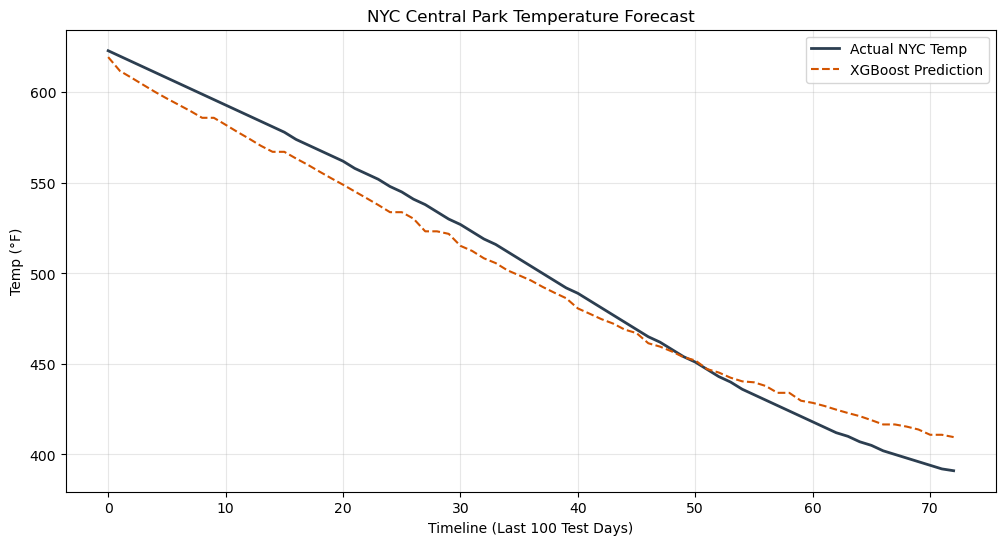

In [2]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
EXTRACTED_FOLDER = 'extracted_stations'
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}
# This matches the column name in the NOAA Global Summary of the Day files
TMAX_COL = 'DLY-TMAX-NORMAL'

# --- 2. DATA LOADING & CLEANING ---
def load_from_extracted():
    """Reads all CSVs, skips broken lines, and cleans dates."""
    all_stations = []
    print(f"--- Loading and Cleaning data from {EXTRACTED_FOLDER} ---")
    
    if not os.path.exists(EXTRACTED_FOLDER):
        raise FileNotFoundError(f"Folder '{EXTRACTED_FOLDER}' not found!")

    for filename in os.listdir(EXTRACTED_FOLDER):
        if filename.endswith('.csv'):
            file_path = os.path.join(EXTRACTED_FOLDER, filename)
            
            try:
                # FIX: Removed low_memory=False because it conflicts with engine='python'
                df = pd.read_csv(
                    file_path, 
                    on_bad_lines='skip', 
                    engine='python'
                )
                
                if TMAX_COL not in df.columns or 'DATE' not in df.columns:
                    continue
                
                # Standardize Date formatting
                if df['DATE'].dtype == 'object':
                    # Ensure we don't have leading spaces and add a year if missing
                    date_str = df['DATE'].astype(str).str.strip()
                    if not date_str.iloc[0].startswith('20'):
                        df['DATE'] = '2024-' + date_str
                
                df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
                df = df.dropna(subset=['DATE'])
                
                # Rename the column for easier processing
                df = df.rename(columns={TMAX_COL: 'TMAX'})
                all_stations.append(df[['DATE', 'STATION', 'TMAX']])
                print(f"Successfully loaded: {filename}")
                
            except Exception as file_error:
                print(f"Skipping {filename} due to: {file_error}")
    
    if not all_stations:
        raise ValueError("No valid data loaded. Check your CSV files and column names.")

    return pd.concat(all_stations)

# --- 3. FEATURE ENGINEERING ---
def engineer_features(df):
    """Pivots data and creates Lag/Seasonal features."""
    # Remove duplicates before pivoting
    df = df.drop_duplicates(subset=['DATE', 'STATION'])
    
    # Pivot: Every station ID gets its own column
    pivot = df.pivot(index='DATE', columns='STATION', values='TMAX')
    
    # Rename columns using our human-readable map
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Lag Features: Give the model 'Yesterday's' weather as a predictor
    for loc in pivot.columns:
        if loc in STATION_MAP.values():
            pivot[f'{loc}_Yesterday'] = pivot[loc].shift(1)
    
    # Seasonal Trigonometry: Helps model understand the 365-day cycle
    day_of_year = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day_of_year / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day_of_year / 365.25)
    
    return pivot.dropna()

# --- 4. MACHINE LEARNING ENGINE ---
def run_experiment(data):
    """Trains XGBoost and evaluates performance."""
    target = 'NYC_CentralPark'
    
    if target not in data.columns:
        raise KeyError(f"Target {target} not found. Check your station map and CSVs.")
        
    y = data[target]
    X = data.drop(columns=[target])
    
    # Chronological Split (Shuffle=False is essential for time-series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    print(f"\n--- Training XGBoost Regressor ---")
    model = XGBRegressor(
        n_estimators=500, 
        learning_rate=0.03, 
        max_depth=5, 
        early_stopping_rounds=10,
        random_state=42
    )
    
    # Train the model
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    preds = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    print(f"Average Error (MAE): {mae:.2f}°F")
    print(f"R2 Score: {r2:.4f}")
    
    return y_test, preds

# --- 5. EXECUTION ---
if __name__ == "__main__":
    try:
        raw_df = load_from_extracted()
        final_data = engineer_features(raw_df)
        actuals, guesses = run_experiment(final_data)
        
        # Visualize the last 100 days of prediction
        plt.figure(figsize=(12, 6))
        plt.plot(actuals.values[-100:], label="Actual NYC Temp", color='#2c3e50', linewidth=2)
        plt.plot(guesses[-100:], label="XGBoost Prediction", color='#d35400', linestyle='--')
        plt.title("NYC Central Park Temperature Forecast")
        plt.ylabel("Temp (°F)")
        plt.xlabel("Timeline (Last 100 Test Days)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"CRITICAL ERROR: {e}")

In [3]:
import pandas as pd  # Data manipulation library
import os             # Library for checking file paths

# --- 1. Configuration ---
# The name of the massive source file (8GB+)
input_file = 'Weather Data (US).csv' 

# The name of the new, smaller file we will create
output_file = 'mid_atlantic_weather.csv'

# A list of Station IDs for specific locations in NYC, NJ, CT, and PA
target_ids = [
    'USW00094728', 'USW00094789', # NYC
    'USW00014734',                # Newark, NJ
    'USW00014752',                # Bridgeport, CT
    'USW00013739',                # Philly, PA
    'USW00014737',                # Allentown, PA
    'USW00014777',                # Scranton, PA
    'USC00368596'                 # E. Stroudsburg, PA
]

# --- 2. The Extraction Process ---
# Check if the source file actually exists before trying to open it
if os.path.exists(input_file):
    print("Large dataset found. Starting extraction (this will take 3-5 minutes)...")
    
    # Initialize an empty list to store the small, filtered data pieces
    chunks = [] 
    
    # Process the file in 'chunks' of 100,000 rows to save RAM/memory
    # Instead of loading 8GB at once, we load a tiny slice, check it, then discard it
    for chunk in pd.read_csv(input_file, chunksize=100000):
        
        # Filter the current chunk: keep only rows where 'ID' matches our list
        filtered = chunk[chunk['ID'].isin(target_ids)]
        
        # Add the filtered results to our chunks list
        chunks.append(filtered)
     
    # Combine all the filtered slices into one single data structure
    final_df = pd.concat(chunks)
    
    # Save the filtered results to a new, much smaller CSV file
    final_df.to_csv(output_file, index=False)
    
    # Print success message and the number of rows found
    print(f"Success! {output_file} created with {len(final_df)} rows.")

else:
    # If the file name is misspelled or missing from the folder
    print(f"CRITICAL ERROR: Could not find '{input_file}'.")
    print("Check your folder and ensure the name matches perfectly!")

Large dataset found. Starting extraction (this will take 3-5 minutes)...
Success! mid_atlantic_weather.csv created with 84004 rows.


--- mid_atlantic_weather.csv already exists. Skipping extraction. ---

--- Model Results ---
Average Prediction Error: 1.16°F


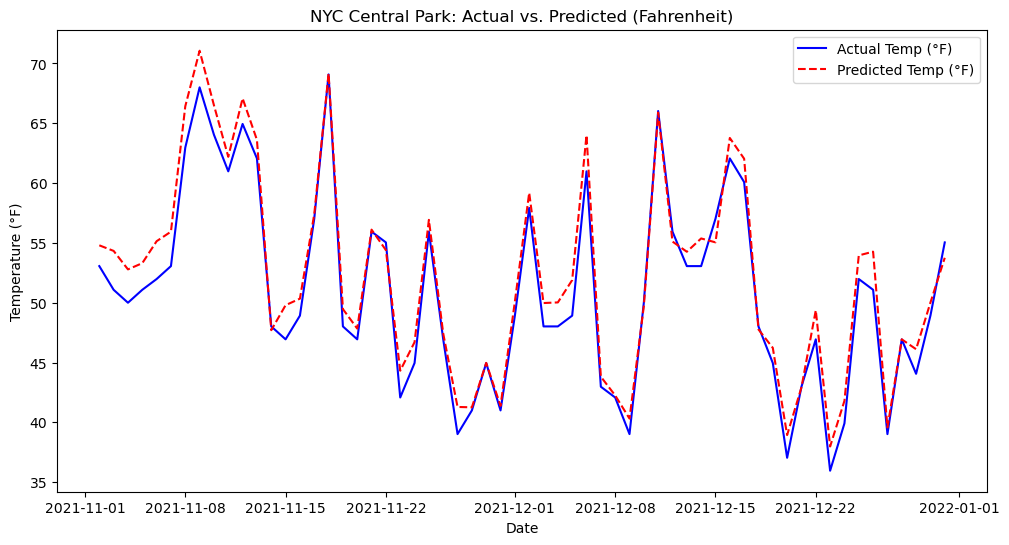

In [4]:
import pandas as pd  # Data handling (DataFrames)
import numpy as np   # Numerical math operations
import os            # File and folder management
from xgboost import XGBRegressor               # The Machine Learning model
from sklearn.model_selection import train_test_split # Tool to split data into training/testing sets
from sklearn.metrics import mean_absolute_error      # Tool to measure how accurate our model is
import matplotlib.pyplot as plt                 # Tool for creating charts and graphs

# Define global constants for file names
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# List of specific NOAA weather station IDs for the Mid-Atlantic region
TARGET_IDS = [
    'USW00094728', 'USW00094789', # NYC (Central Park & JFK)
    'USW00014734',                # Newark, NJ
    'USW00014752',                # Bridgeport, CT
    'USW00013739',                # Philadelphia, PA
    'USW00014737',                # Allentown, PA
    'USW00014777',                # Scranton, PA
    'USC00368596'                 # East Stroudsburg, PA
]

def extract_regional_data():
    """Extracts only our target cities from the massive 8GB file."""
    # Only run extraction if the smaller file doesn't already exist
    if not os.path.exists(PROCESSED_FILE):
        print(f"--- Extracting regional data from {INPUT_FILE} ---")
        chunks = [] # List to hold filtered pieces of data
        
        # Read the huge file 100,000 rows at a time to prevent memory crashes
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000):
            # Keep only the rows that match our TARGET_IDS
            filtered = chunk[chunk['ID'].isin(TARGET_IDS)]
            chunks.append(filtered)
        
        # Glue all the small pieces back together into one table
        final_df = pd.concat(chunks)
        # Save this much smaller dataset to your hard drive
        final_df.to_csv(PROCESSED_FILE, index=False)
        print(f"--- Extraction Complete! Saved to {PROCESSED_FILE} ---")
    else:
        # If the file is already there, don't waste time extracting again
        print(f"--- {PROCESSED_FILE} already exists. Skipping extraction. ---")


def load_and_clean_data():
    """Fixes units and prepares the data for analysis."""
    df = pd.read_csv(PROCESSED_FILE) # Load the filtered CSV
    df['DATE'] = pd.to_datetime(df['DATE']) # Convert date strings to actual Date objects
    
    # NOAA data is stored in tenths of Celsius; convert to Fahrenheit
    for col in ['TMAX', 'TMIN']:
        if col in df.columns:
            # (Tenths / 10) gives Celsius, then * 1.8 + 32 gives Fahrenheit
            df[col] = ( (df[col] / 10) * 1.8 ) + 32
            
    # Standardize Rainfall (tenths of mm to mm)
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'] / 10
        
    return df

def run_weather_model(df):
    """Builds and tests the XGBoost AI model."""
    # Pivot the table: Dates become rows, Station IDs become columns, TMAX is the value
    df_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # FEATURE ENGINEERING: Create "Lag" columns (Yesterday's temp for every city)
    for city_id in df_pivot.columns:
        df_pivot[f'{city_id}_yesterday'] = df_pivot[city_id].shift(1)
    
    # SEASONALITY: Convert months into a circular wave (Sine/Cosine) 
    # This helps the AI understand that December (12) is close to January (1)
    df_pivot['month_sin'] = np.sin(2 * np.pi * df_pivot.index.month / 12)
    df_pivot['month_cos'] = np.cos(2 * np.pi * df_pivot.index.month / 12)
    
    # Drop the first row because it won't have a "yesterday" value (NaN)
    df_ml = df_pivot.dropna()
    
    # Define our target: We want to predict NYC Central Park (USW00094728)
    y = df_ml['USW00094728']
    # Define our features: Everything else except the target itself
    X = df_ml.drop(columns=['USW00094728'])
    
    # Split data: 80% for training, 20% for testing. 
    # shuffle=False is critical for time series so we don't predict the past with the future.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Initialize the XGBoost model with specific settings (Learning rate and tree depth)
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
    # The actual "Learning" step: the model looks for patterns in the training data
    model.fit(X_train, y_train)
    
    # Test the model: Have it predict temps for the 'X_test' dates it hasn't seen yet
    predictions = model.predict(X_test)
    
    # Calculate Mean Absolute Error (The average number of degrees the model was off)
    error = mean_absolute_error(y_test, predictions)
    print(f"\n--- Model Results ---")
    print(f"Average Prediction Error: {error:.2f}°F")
    
    return y_test, predictions

# --- MAIN EXECUTION BLOCK ---
if __name__ == "__main__":
    # Check if the 8GB file is present before starting
    if os.path.exists(INPUT_FILE):
        extract_regional_data()      # Step 1: Filter raw data
        weather_df = load_and_clean_data() # Step 2: Clean and convert units
        y_test, y_pred = run_weather_model(weather_df) # Step 3: Run AI model
        
        # Step 4: Create a visual graph of the last 60 days to see how we did
        plt.figure(figsize=(12, 6))
        plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Temp (°F)', color='blue')
        plt.plot(y_test.index[-60:], y_pred[-60:], label='Predicted Temp (°F)', color='red', linestyle='--')
        plt.title("NYC Central Park: Actual vs. Predicted (Fahrenheit)")
        plt.xlabel("Date")
        plt.ylabel("Temperature (°F)")
        plt.legend()
        plt.show() # Display the window
    else:
        # Error message if the huge dataset is missing
        print(f"Error: Please place '{INPUT_FILE}' in this folder.")

--- mid_atlantic_weather.csv already exists. Skipping extraction. ---

--- Model Results ---
Average Prediction Error: 1.16°F


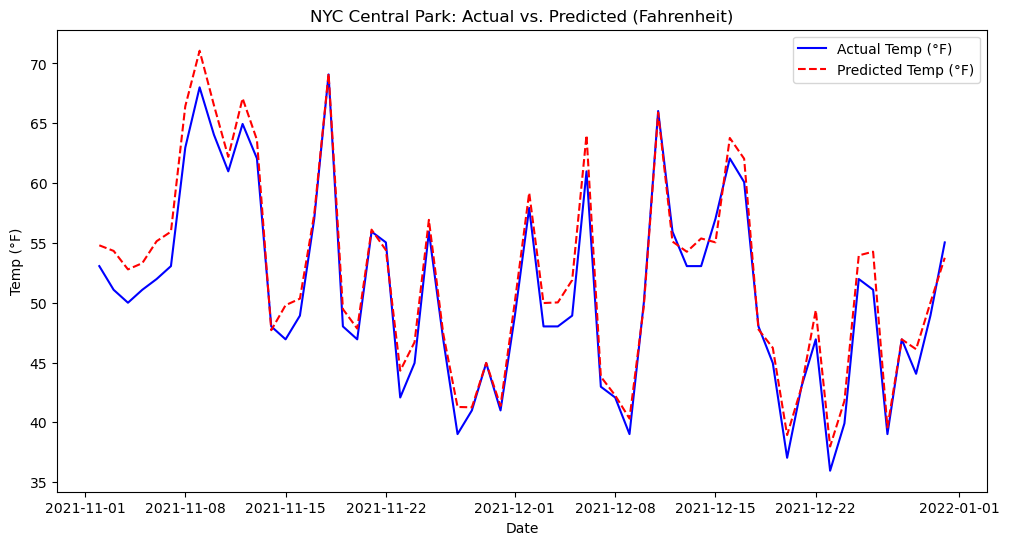

In [5]:
import pandas as pd  # Library for data manipulation and analysis
import numpy as np   # Library for mathematical operations (used for trig functions)
import os            # Library for interacting with the operating system (checking files)
from xgboost import XGBRegressor  # The machine learning algorithm for regression
from sklearn.model_selection import train_test_split  # Splits data into training and testing sets
from sklearn.metrics import mean_absolute_error       # Measures model accuracy
import matplotlib.pyplot as plt                       # Library for creating visualizations

# Define file names as constants for easy updates
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# List of specific NOAA weather station IDs for the Mid-Atlantic region
TARGET_IDS = [
    'USW00094728', 'USW00094789', # NYC (Central Park & JFK)
    'USW00014734',                # Newark, NJ
    'USW00014752',                # Bridgeport, CT
    'USW00013739',                # Philadelphia, PA
    'USW00014737',                # Allentown, PA
    'USW00014777',                # Scranton, PA
    'USC00368596'                 # East Stroudsburg, PA
]

def extract_regional_data():
    """Reads a massive file in chunks to filter out only the stations we need."""
    # Check if we've already done this work to save time
    if not os.path.exists(PROCESSED_FILE):
        print(f"--- Extracting regional data from {INPUT_FILE} ---")
        chunks = []
        # Process the 8GB file 100,000 lines at a time to stay within RAM limits
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000):
            # Filter the chunk for our specific station IDs
            filtered = chunk[chunk['ID'].isin(TARGET_IDS)]
            chunks.append(filtered)
        
        # Combine all the small filtered pieces into one DataFrame
        final_df = pd.concat(chunks)
        # Save to a much smaller CSV for faster loading later
        final_df.to_csv(PROCESSED_FILE, index=False)
        print(f"--- Extraction Complete! Saved to {PROCESSED_FILE} ---")
    else:
        print(f"--- {PROCESSED_FILE} already exists. Skipping extraction. ---")


def load_and_clean_data():
    """Loads the smaller file and fixes units/data types."""
    df = pd.read_csv(PROCESSED_FILE)
    # Convert 'DATE' column strings into actual datetime objects
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # NOAA stores temp in tenths of Celsius (e.g., 200 = 20.0°C)
    # This loop converts them to standard Fahrenheit
    for col in ['TMAX', 'TMIN']:
        if col in df.columns:
            # Formula: (Celsius * 1.8) + 32
            df[col] = ( (df[col] / 10) * 1.8 ) + 32
            
    # Convert precipitation from tenths of mm to mm
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'] / 10
        
    return df

def run_weather_model(df):
    """Prepares features and trains the XGBoost model."""
    # Pivot the data so each Station ID has its own column of TMAX values
    df_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # FEATURE ENGINEERING: Create "Lag Features"
    # This tells the model what the temperature was yesterday at every station
    for city_id in df_pivot.columns:
        df_pivot[f'{city_id}_yesterday'] = df_pivot[city_id].shift(1)
    
    # CYCLICAL TIME FEATURES:
    # Use Sine and Cosine to help the AI understand that Dec (12) is next to Jan (1)
    df_pivot['month_sin'] = np.sin(2 * np.pi * df_pivot.index.month / 12)
    df_pivot['month_cos'] = np.cos(2 * np.pi * df_pivot.index.month / 12)
    
    # Remove rows with NaN (the first day has no "yesterday" data)
    df_ml = df_pivot.dropna()
    
    # Target (y): What we want to predict (NYC Central Park)
    y = df_ml['USW00094728']
    # Features (X): Everything else we use to make the prediction
    X = df_ml.drop(columns=['USW00094728'])
    
    # Split data: Train on 80% of data, Test on the most recent 20%
    # shuffle=False is vital for Time Series to avoid "predicting the past with the future"
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Setup the XGBoost model (100 trees, learning rate 0.1)
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
    # Train the model to find patterns between X (regional weather) and y (NYC weather)
    model.fit(X_train, y_train)
    
    # Make predictions on the test set (the data the model hasn't seen)
    predictions = model.predict(X_test)
    # Calculate the average difference between predictions and reality
    error = mean_absolute_error(y_test, predictions)
    print(f"\n--- Model Results ---")
    print(f"Average Prediction Error: {error:.2f}°F")
    
    return y_test, predictions

# --- Main Logic ---
if __name__ == "__main__":
    # Ensure the original 8GB file is present in the folder
    if os.path.exists(INPUT_FILE):
        extract_regional_data()           # Step 1: Filter Big Data
        weather_df = load_and_clean_data()      # Step 2: Format and Clean
        y_test, y_pred = run_weather_model(weather_df) # Step 3: AI Training/Testing
        
        # Step 4: Visualization - Plotting the actual vs predicted for the last 2 months
        plt.figure(figsize=(12, 6))
        plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Temp (°F)', color='blue')
        plt.plot(y_test.index[-60:], y_pred[-60:], label='Predicted Temp (°F)', color='red', linestyle='--')
        plt.title("NYC Central Park: Actual vs. Predicted (Fahrenheit)")
        plt.xlabel("Date")
        plt.ylabel("Temp (°F)")
        plt.legend()
        plt.show() # Pop up the chart
    else:
        print(f"Error: Please place '{INPUT_FILE}' in this folder.")

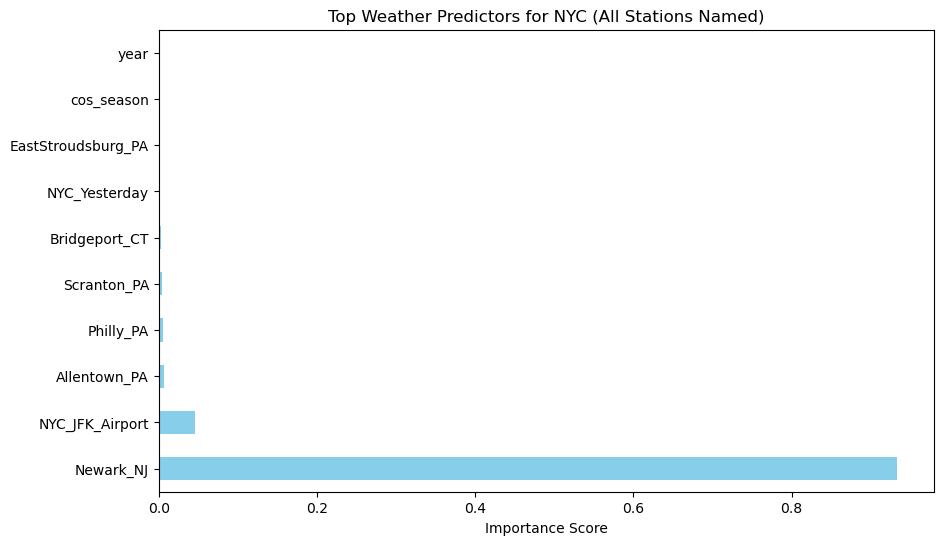

In [6]:
import pandas as pd  # Data manipulation (DataFrames)
import numpy as np   # Math operations (Sine/Cosine for seasons)
import os            # File system checks
from xgboost import XGBRegressor                    # The Gradient Boosting AI model
from sklearn.model_selection import train_test_split # Logic to split data into Train/Test sets
from sklearn.metrics import mean_absolute_error, r2_score # Accuracy measuring tools
import matplotlib.pyplot as plt                     # Data visualization/graphing

# --- Configuration ---
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# A dictionary to translate NOAA station IDs into friendly city names
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def extract_and_clean():
    """Extracts only the stations we want and converts units."""
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data (3-5 mins)... ---")
        # Use a list comprehension to read the 8GB file in chunks and keep only our target IDs
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        # Combine the filtered chunks and save them to a new, small CSV
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    # Load the newly created regional file
    df = pd.read_csv(PROCESSED_FILE)
    # Convert 'DATE' text into actual Python Date objects
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Convert NOAA's tenths of Celsius into standard Fahrenheit
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
    return df

def engineer_features(df):
    """Turns raw temperature data into 'features' the AI can learn from."""
    # Pivot the data: Rows = Dates, Columns = Station IDs, Values = Max Temp
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # Use the STATION_MAP dictionary to rename the columns from IDs to City Names
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # LAG FEATURES: Create "Yesterday" columns to give the model 'memory'
    pivot['NYC_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['Philly_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    
    # SEASONAL FEATURES: Use Sine and Cosine waves based on the day of the year (1-365)
    # This teaches the AI the circular nature of spring, summer, fall, and winter
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    pivot['year'] = pivot.index.year # Helps the model account for long-term climate trends
    
    # Drop the first row because 'shift(1)' creates a missing value (NaN) for the first day
    return pivot.dropna()


# --- Execution ---
if __name__ == "__main__":
    # Check if the source 8GB file exists before starting
    if os.path.exists(INPUT_FILE):
        raw_df = extract_and_clean()       # Step 1: Filter and clean units
        data = engineer_features(raw_df)   # Step 2: Create AI features (Lags and Seasons)
        
        # Define the Target (y) and the Predictors (X)
        y = data['NYC_CentralPark']        # We want to predict NYC Central Park
        X = data.drop(columns=['NYC_CentralPark']) # Using every other city/feature
        
        # Split into training (80%) and testing (20%) data
        # shuffle=False ensures we test on the "future" and train on the "past"
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        # Initialize XGBoost with specific learning parameters
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5)
        # Train the model: look for connections between regional weather and NYC weather
        model.fit(X_train, y_train)
        
        # VISUALIZATION: Plot Feature Importance
        # This shows which cities/features were most useful in predicting NYC's temp
        plt.figure(figsize=(10, 6))
        # Take the top 10 most influential features and plot them as a horizontal bar chart
        pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh', color='skyblue')
        plt.title("Top Weather Predictors for NYC (All Stations Named)")
        plt.xlabel("Importance Score")
        plt.show()
    else:
        # Standard error message if the dataset isn't in the folder
        print(f"Missing '{INPUT_FILE}'")


    ERROR COMPARISON REPORT
[With Newark]
  - Avg Error (MAE): 1.13°F
  - Accuracy (R2):   0.9931
------------------------------
[Without Newark]
  - Avg Error (MAE): 1.32°F
  - Accuracy (R2):   0.9894
------------------------------


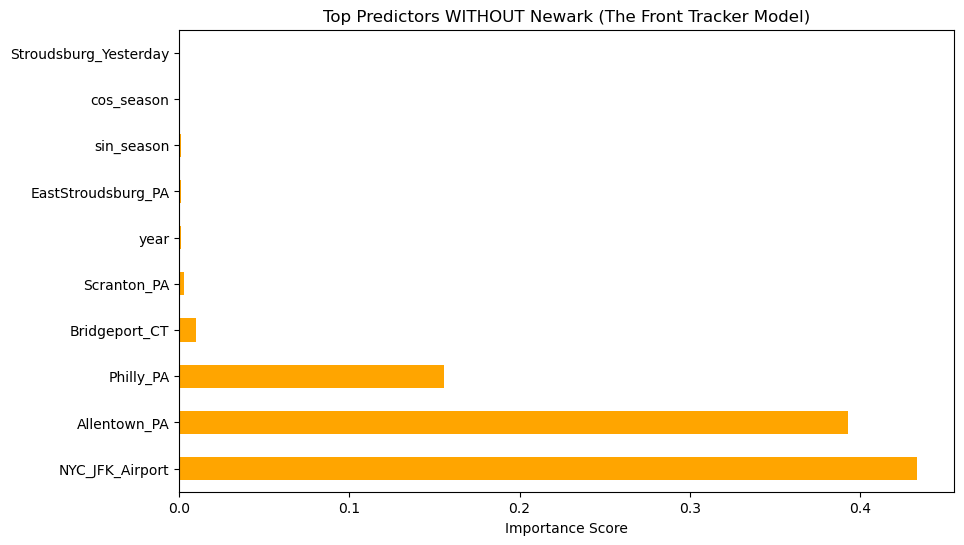

In [7]:
import pandas as pd  # Data manipulation
import numpy as np   # Numerical operations
import os            # File path management
from xgboost import XGBRegressor                    # The Gradient Boosting machine learning model
from sklearn.model_selection import train_test_split # Tool to split data into training and testing
from sklearn.metrics import mean_absolute_error, r2_score # Metrics to evaluate performance
import matplotlib.pyplot as plt                     # Graphing and visualization

# --- Configuration ---
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# Map of NOAA IDs to Human-Readable Names
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def extract_and_clean():
    """Extracts target stations from the 8GB file and converts units."""
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data (3-5 mins)... ---")
        # Generator: reads the big file in chunks to filter IDs without overloading RAM
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE']) # Convert date strings to datetime objects
    
    # Convert temperature from tenths of Celsius to Fahrenheit
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
    return df

def engineer_features(df):
    """Creates historical 'memory' and seasonal patterns for the AI."""
    # Pivot so each station is its own column
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    # Rename columns using our STATION_MAP
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # LAG FEATURES: Create 'Yesterday' columns for key cities
    # This allows the model to see how weather moved across the region the day before
    pivot['NYC_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['Philly_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    
    # CYCLICAL TIME: Convert day-of-year into Sine/Cosine waves
    # This correctly represents that Jan 1 is close to Dec 31
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    pivot['year'] = pivot.index.year
    
    return pivot.dropna() # Remove the first row containing NaNs from the shifts

def run_comparison(data):
    """Trains two versions of the model to see how much Newark influences predictions."""
    results = {}
    
    # Define the Target (y): Always NYC Central Park
    y = data['NYC_CentralPark']
    
    # Experiment A: Baseline using all available regional data
    X_with = data.drop(columns=['NYC_CentralPark'])
    
    # Experiment B: Removing Newark to see if we can still predict NYC using 'further' cities
    X_without = data.drop(columns=['NYC_CentralPark', 'Newark_NJ'])
    
    datasets = {"With Newark": X_with, "Without Newark": X_without}
    
    for name, X in datasets.items():
        # Split data into 80% Train and 20% Test (shuffle=False preserves time order)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        # Initialize and train the XGBoost Regressor
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5)
        model.fit(X_train, y_train)
        
        # Generate predictions and calculate accuracy metrics
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds) # Mean Absolute Error (lower is better)
        r2 = r2_score(y_test, preds)             # R-Squared (closer to 1.0 is better)
        
        # Store results for the final report
        results[name] = {'MAE': mae, 'R2': r2, 'Model': model, 'Features': X.columns}
        
    return results


if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        # 1. Clean and Prepare
        raw_df = extract_and_clean()
        ml_data = engineer_features(raw_df)
        
        # 2. Run the Comparison Experiment
        comparison = run_comparison(ml_data)
        
        # 3. Print the Comparison Report
        print("\n" + "="*30)
        print("    ERROR COMPARISON REPORT")
        print("="*30)
        for name, metrics in comparison.items():
            print(f"[{name}]")
            print(f"  - Avg Error (MAE): {metrics['MAE']:.2f}°F")
            print(f"  - Accuracy (R2):   {metrics['R2']:.4f}")
            print("-" * 30)

        # 4. Visualize 'Feature Importance' for the model without Newark
        # This shows us what the "next best" predictors are when Newark is gone
        plt.figure(figsize=(10, 6))
        no_newark_metrics = comparison['Without Newark']
        pd.Series(no_newark_metrics['Model'].feature_importances_, 
                  index=no_newark_metrics['Features']).nlargest(10).plot(kind='barh', color='orange')
        plt.title("Top Predictors WITHOUT Newark (The Front Tracker Model)")
        plt.xlabel("Importance Score")
        plt.show()
    else:
        print(f"Missing '{INPUT_FILE}'")


--- RESULTS: NYC RAIN FORECAST (Newark Removed) ---
Average Prediction Error: 1.81 mm


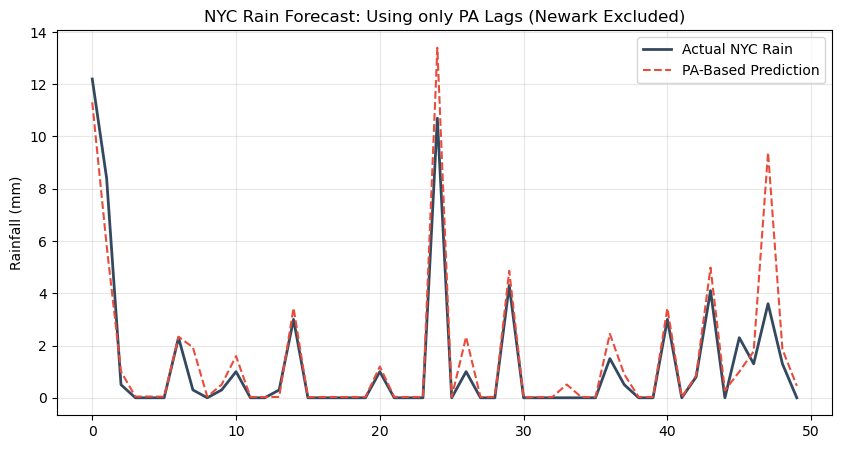

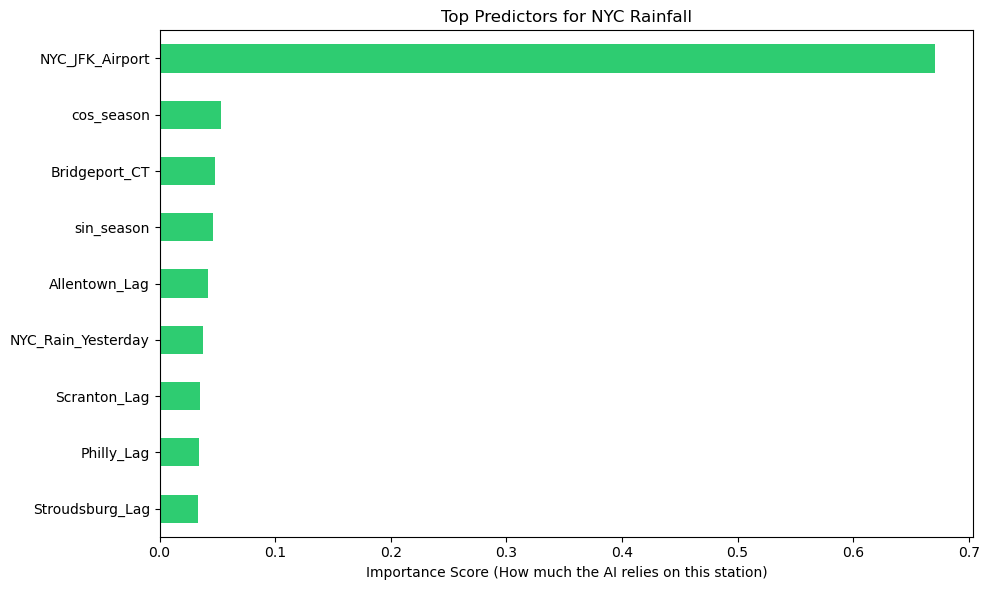

In [8]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- A. SETUP ---
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}


def load_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("Please ensure you have run the extraction step first.")
        return None
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Tenths of mm -> mm
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'].fillna(0) / 10 
    return df

def engineer_features(df):
    # Pivot on Precipitation
    pivot = df.pivot(index='DATE', columns='ID', values='PRCP')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # --- TRUE FORECASTING LOGIC ---
    # Create 24-hour lags for all Pennsylvania stations
    # This means we use YESTERDAY'S PA rain to predict TODAY'S NYC rain
    pivot['Philly_Lag'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Lag'] = pivot['Allentown_PA'].shift(1)
    pivot['Scranton_Lag'] = pivot['Scranton_PA'].shift(1)
    pivot['Stroudsburg_Lag'] = pivot['EastStroudsburg_PA'].shift(1)
    
    # Persistence: Did it rain in NYC yesterday?
    pivot['NYC_Rain_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    
    # Seasonal encoding
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return pivot.dropna()

def run_experiment(data):
    # 1. Target: NYC Central Park
    y = data['NYC_CentralPark']
    
    # 2. DROP NEWARK & CURRENT DAY DATA
    # We remove Newark entirely and the current-day values of PA cities.
    # The model is now FORCED to use only the 'Lags' (yesterday's data).
    cols_to_drop = [
        'NYC_CentralPark', 'Newark_NJ', 
        'Philly_PA', 'Allentown_PA', 'Scranton_PA', 'EastStroudsburg_PA'
    ]
    X = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Train
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
    model.fit(X_train, y_train)
    
    preds = np.maximum(model.predict(X_test), 0)
    
    print(f"\n--- RESULTS: NYC RAIN FORECAST (Newark Removed) ---")
    print(f"Average Prediction Error: {mean_absolute_error(y_test, preds):.2f} mm")
    
    return X, y_test, preds, model

if __name__ == "__main__":
    clean_df = load_and_clean()
    if clean_df is not None:
        final_data = engineer_features(clean_df)
        X_features, actuals, guesses, my_model = run_experiment(final_data)
        
        # --- PLOT 1: FORECAST ACCURACY ---
        plt.figure(figsize=(10, 5))
        plt.plot(actuals.tail(50).values, label="Actual NYC Rain", color='#34495e', linewidth=2)
        plt.plot(guesses[-50:], label="PA-Based Prediction", color='#e74c3c', linestyle='--')
        plt.title("NYC Rain Forecast: Using only PA Lags (Newark Excluded)")
        plt.ylabel("Rainfall (mm)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # --- PLOT 2: TOP PREDICTORS (Feature Importance) ---
        plt.figure(figsize=(10, 6))
        # Get importances and sort them
        importances = pd.Series(my_model.feature_importances_, index=X_features.columns)
        importances.sort_values().plot(kind='barh', color='#2ecc71')
        
        plt.title("Top Predictors for NYC Rainfall")
        plt.xlabel("Importance Score (How much the AI relies on this station)")
        plt.tight_layout()
        plt.show()


  FINAL WEATHER & COMMERCE REPORT
NYC Temp Error (PA Lead Time): 1.44°F
NYC Rain Predictability:      60.3%
----------------------------------------


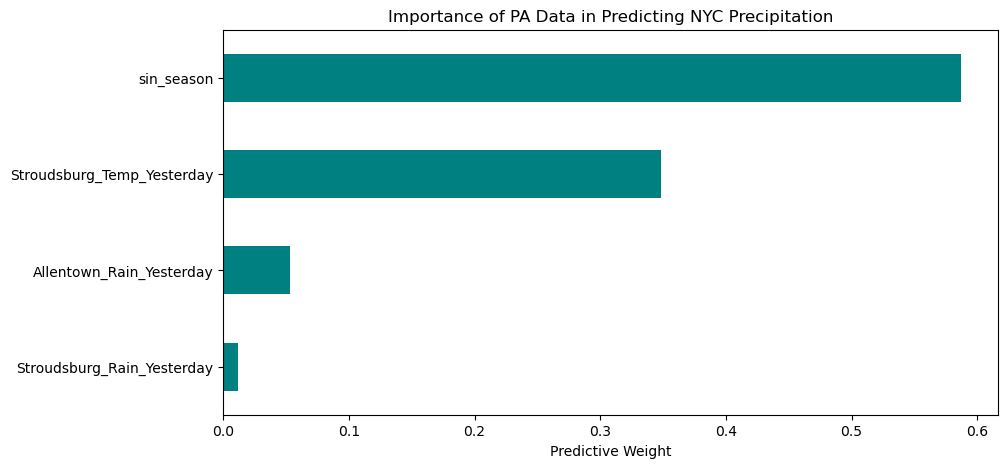

In [9]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier  # New: For predicting 'Yes/No' rain
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
import matplotlib.pyplot as plt

# 1. SETUP & MAPPING
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# Mapping NOAA IDs to friendly names for better analysis
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014734': 'Newark_NJ',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00014752': 'Bridgeport_CT'
}

# 2. DATA EXTRACTION & CLEANING
def extract_and_clean():
    """Filters the 8GB file and handles unit conversions."""
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        # Use chunking to avoid memory errors with the massive dataset
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Convert tenths of Celsius -> Fahrenheit
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
        
    # Convert Precipitation (tenths of mm -> mm) and fill missing values with 0
    df['PRCP'] = df['PRCP'].fillna(0) / 10
    
    # CLASSIFICATION TARGET: If rain is > 0.1mm, mark it as a '1' (Rainy Day)
    df['is_raining'] = (df['PRCP'] > 0.1).astype(int)
    
    return df

# 3. FEATURE ENGINEERING
def engineer_all_features(df):
    """Creates the 'Lead Time' features by shifting data from the past."""
    # Create two tables: one for temperature and one for rain status
    temp_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    rain_pivot = df.pivot(index='DATE', columns='ID', values='is_raining')
    
    # Rename columns from IDs to names like 'NYC_CentralPark'
    temp_pivot.columns = [STATION_MAP.get(c, c) for c in temp_pivot.columns]
    rain_pivot.columns = [STATION_MAP.get(c, c) for c in rain_pivot.columns]
    
    # --- LEAD TIME FEATURES ---
    # We want to see if PA's weather yesterday helps predict NYC's weather today
    features = temp_pivot.copy()
    features['NYC_Temp_Yesterday'] = temp_pivot['NYC_CentralPark'].shift(1)
    features['Stroudsburg_Temp_Yesterday'] = temp_pivot['EastStroudsburg_PA'].shift(1)
    
    # RAIN LAGS: Did it rain in PA yesterday?
    features['Stroudsburg_Rain_Yesterday'] = rain_pivot['EastStroudsburg_PA'].shift(1)
    features['Allentown_Rain_Yesterday'] = rain_pivot['Allentown_PA'].shift(1)
    
    # TARGET: This is the column we want the AI to predict (Rain in NYC Today)
    features['Target_NYC_Rain'] = rain_pivot['NYC_CentralPark']
    
    # SEASONAL AWARENESS: Cyclical encoding for the time of year
    day = features.index.dayofyear
    features['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    features['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return features.dropna() # Remove rows where shifted data is missing

# 4. WEATHER & COMMERCE INTELLIGENCE (The Analysis)
def run_analysis(data):
    """Trains a Regressor for temperature and a Classifier for rain."""
    
    # PART A: TEMPERATURE PREDICTION (XGBoost Regressor)
    # We drop NYC today and Newark to see how well PA predicts NYC on its own
    y_t = data['NYC_CentralPark']
    X_t = data.drop(columns=['NYC_CentralPark', 'Target_NYC_Rain', 'Newark_NJ'], errors='ignore')
    
    # Time Series Split (80/20)
    Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_t, y_t, test_size=0.2, shuffle=False)
    t_model = XGBRegressor(n_estimators=100).fit(Xt_tr, yt_tr)
    t_mae = mean_absolute_error(yt_te, t_model.predict(Xt_te))

    # PART B: RAIN PREDICTION (Random Forest Classifier)
    # Predicting if it will rain in NYC today using only PA weather from yesterday
    y_r = data['Target_NYC_Rain']
    X_r = data[['Stroudsburg_Rain_Yesterday', 'Allentown_Rain_Yesterday', 
                'Stroudsburg_Temp_Yesterday', 'sin_season']]
    
    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_r, y_r, test_size=0.2, shuffle=False)
    r_model = RandomForestClassifier(n_estimators=100).fit(Xr_tr, yr_tr)
    # Measure accuracy: How often was the rain prediction correct?
    r_acc = accuracy_score(yr_te, r_model.predict(Xr_te))
    
    return t_mae, r_acc, r_model, X_r.columns

# 5. EXECUTION
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        # Run the full pipeline
        raw_df = extract_and_clean()
        ml_data = engineer_all_features(raw_df)
        mae, rain_acc, rain_model, rain_cols = run_analysis(ml_data)
        
        # Display the Summary Report
        print("\n" + "="*40)
        print("  FINAL WEATHER & COMMERCE REPORT")
        print("="*40)
        print(f"NYC Temp Error (PA Lead Time): {mae:.2f}°F")
        print(f"NYC Rain Predictability:      {rain_acc*100:.1f}%")
        print("-" * 40)
        
        # VISUALIZATION: Show which PA features most heavily influence NYC rain
        plt.figure(figsize=(10, 5))
        pd.Series(rain_model.feature_importances_, index=rain_cols).plot(kind='barh', color='teal')
        plt.title("Importance of PA Data in Predicting NYC Precipitation")
        plt.xlabel("Predictive Weight")
        plt.show()
    else:
        print(f"Error: {INPUT_FILE} not found.")


--------------------------------------------------
  REGIONAL COMMERCE IMPACT REPORT (%)
--------------------------------------------------
Commerce_Impact     High Friction (Logistics & Transport Delays)  \
EastStroudsburg_PA                                         17.68   
Philly_PA                                                  15.47   
Newark_NJ                                                  16.07   
Allentown_PA                                               17.02   
Bridgeport_CT                                              15.15   
Scranton_PA                                                15.74   
NYC_CentralPark                                            16.93   
NYC_JFK_Airport                                            15.25   

Commerce_Impact     Low Friction (High Foot Traffic)  \
EastStroudsburg_PA                             60.38   
Philly_PA                                      66.64   
Newark_NJ                                      66.04   
Allentown_PA          

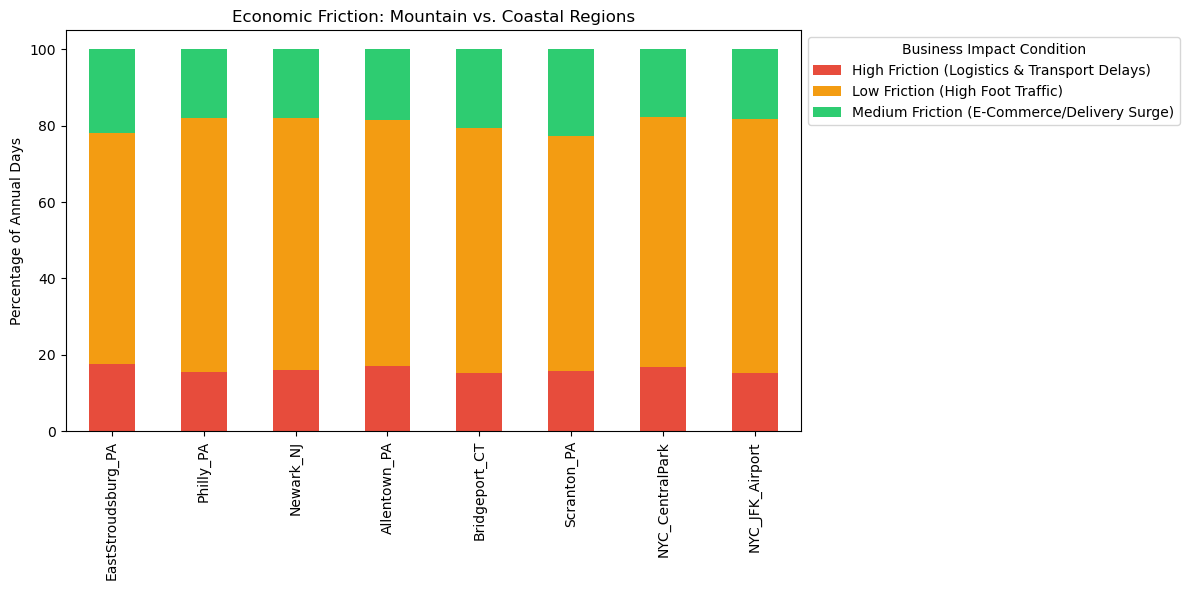

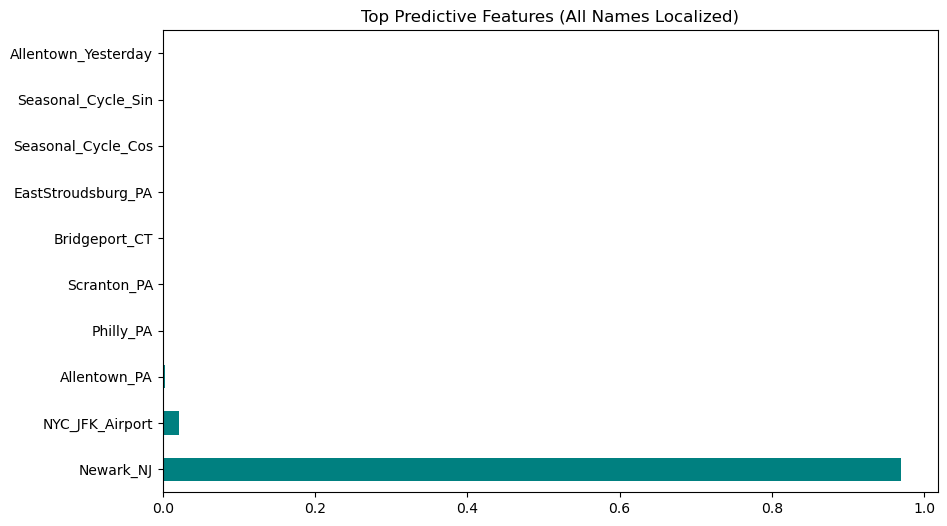

In [10]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- 1. SETUP & COMPLETE DICTIONARY ---
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# Maps cryptic NOAA Station IDs to readable city names for business reporting
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014734': 'Newark_NJ',
    'USW00014752': 'Bridgeport_CT',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014777': 'Scranton_PA',
    'USC00368596': 'EastStroudsburg_PA'
}

# --- 2. DATA EXTRACTION & ENHANCED CLEANING ---
def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        # List comprehension to filter the huge 8GB file by our STATION_MAP keys in chunks
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE']) # Ensures Python recognizes dates correctly
    
    # Unit Conversion: NOAA uses tenths of Celsius. We fill blanks with 0 and convert to Fahrenheit.
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col].fillna(0) / 10) * 1.8) + 32
    
    # Standardize Precipitation (PRCP) from tenths of mm to mm
    df['PRCP'] = df['PRCP'].fillna(0) / 10
    
    # BUSINESS LOGIC: Translates raw rain numbers into economic impact categories
    def categorize_commerce_impact(prcp):
        if prcp == 0: 
            return "Low Friction (High Foot Traffic)"         # Great day for physical retail
        elif prcp < 5: 
            return "Medium Friction (E-Commerce/Delivery Surge)" # People stay home and order in
        else: 
            return "High Friction (Logistics & Transport Delays)" # Heavy rain/snow slows down trucks
    
    # Apply the logic to every row in the dataset
    df['Commerce_Impact'] = df['PRCP'].apply(categorize_commerce_impact)
    return df

# --- 3. FEATURE ENGINEERING (Seasonal & Lead Time) ---
def engineer_features(df):
    # Pivot the data: Rows are Dates, Columns are Stations, Values are Max Temp
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # RENAME ALL COLUMNS IMMEDIATELY using the STATION_MAP dictionary
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Seasonal Awareness (Sin/Cos): Helps the AI understand January (1) is near December (12)
    # This prevents the model from thinking the months are a linear 1-12 scale.
    day = pivot.index.dayofyear
    pivot['Seasonal_Cycle_Sin'] = np.sin(2 * np.pi * day / 365.25)
    pivot['Seasonal_Cycle_Cos'] = np.cos(2 * np.pi * day / 365.25)
    
    # PA LEAD TIME FEATURES: "The Front Tracker"
    # Shifts PA mountain data by 1 day to see if they are 'leading indicators' for NYC
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    
    return pivot.dropna() # Remove the first row which is now empty due to the shift

# --- 4. EXECUTION & VISUALIZATION ---
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        df = extract_and_clean()
        
        # --- Part A: Regional Commerce Report ---
        # Calculate how often each city experiences different economic weather conditions
        impact_stats = df.groupby(['ID', 'Commerce_Impact']).size().unstack(fill_value=0)
        impact_stats.index = [STATION_MAP.get(idx, idx) for idx in impact_stats.index]
        # Turn raw counts into percentages for a fair comparison between cities
        impact_pct = impact_stats.div(impact_stats.sum(axis=1), axis=0) * 100
        
        print("\n" + "-"*50)
        print("  REGIONAL COMMERCE IMPACT REPORT (%)")
        print("-"*50)
        print(impact_pct.round(2))
        
        # Visualization 1: Stacked bar chart showing "Friction" levels per city
        impact_pct.plot(kind='bar', stacked=True, figsize=(12, 6), 
                       color=['#e74c3c', '#f39c12', '#2ecc71'])
        plt.title("Economic Friction: Mountain vs. Coastal Regions")
        plt.ylabel("Percentage of Annual Days")
        plt.legend(title="Business Impact Condition", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()

        # --- Part B: Machine Learning ---
        ml_data = engineer_features(df)
        y = ml_data['NYC_CentralPark'] # The Target: Predict NYC's temperature
        X = ml_data.drop(columns=['NYC_CentralPark']) # The Features: Everything else
        
        # Split data chronologically (shuffle=False is vital for time-series weather)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        # Train the XGBoost model (Extreme Gradient Boosting)
        model = XGBRegressor().fit(X_train, y_train)
        
        # Visualization 2: Feature Importance
        # Shows which factors (like PA temps or seasonal cycle) most influenced the NYC prediction
        plt.figure(figsize=(10, 6))
        pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh', color='teal')
        plt.title("Top Predictive Features (All Names Localized)")
        plt.show()

    else:
        print(f"File {INPUT_FILE} not found. Please place it in the script directory.")


   COMMERCE FRICTION REPORT: BY REGIONAL STATION (%)
Commerce_Impact     Extreme Friction (Snow/Icing Risk)  \
EastStroudsburg_PA                                0.59   
Philly_PA                                         0.22   
Newark_NJ                                         0.36   
Allentown_PA                                      0.44   
Bridgeport_CT                                     0.32   
Scranton_PA                                       0.26   
NYC_CentralPark                                   0.31   
NYC_JFK_Airport                                   0.22   

Commerce_Impact     High Friction (Logistics/Flood Delays)  \
EastStroudsburg_PA                                    8.97   
Philly_PA                                             7.77   
Newark_NJ                                             8.46   
Allentown_PA                                          7.98   
Bridgeport_CT                                         7.45   
Scranton_PA                                        

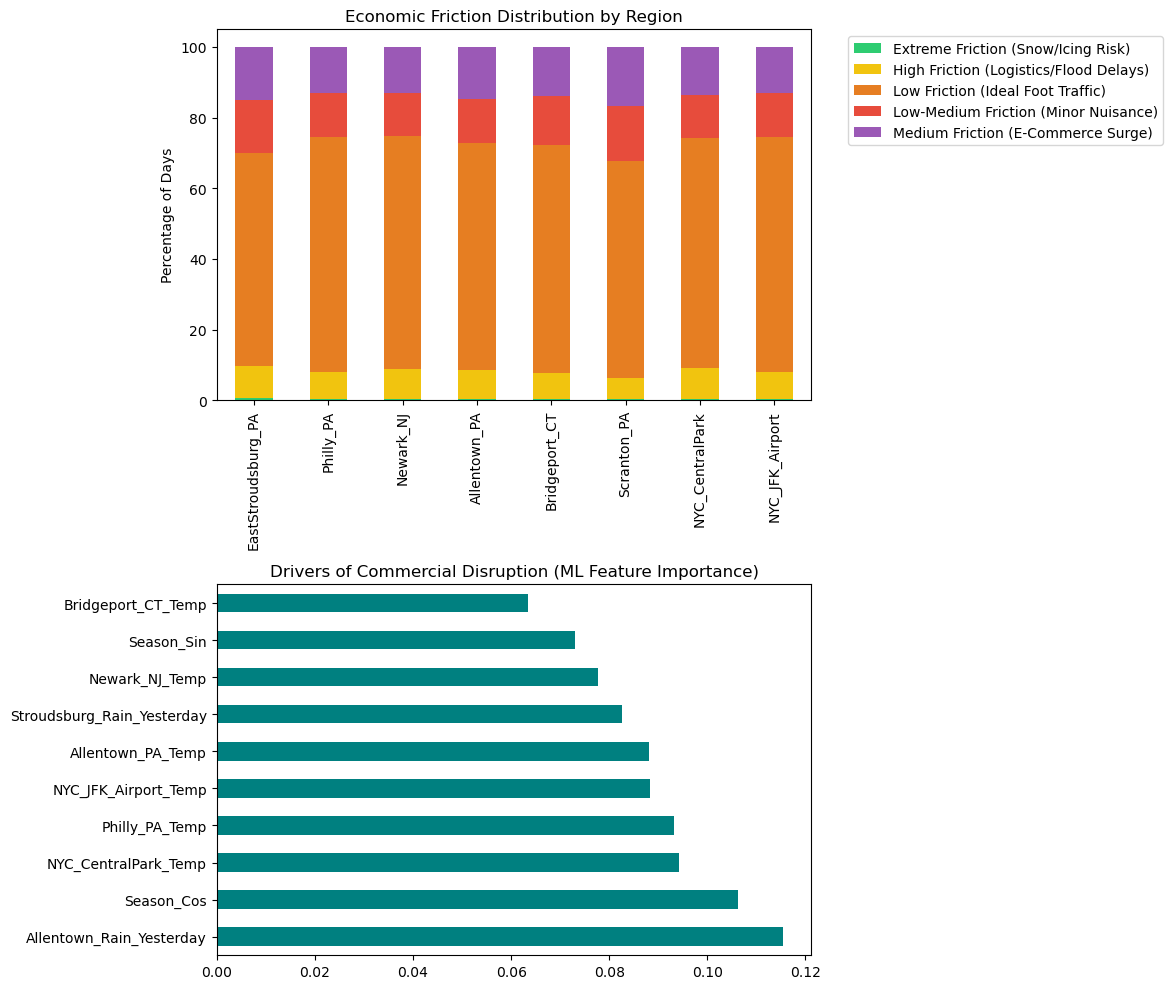

In [11]:
import pandas as pd  # Data manipulation and CSV handling
import numpy as np   # Mathematical operations (Sine/Cosine/Calculations)
import os            # Interacting with the computer's file system
from xgboost import XGBRegressor                    # Advanced Gradient Boosting ML model
from sklearn.model_selection import train_test_split # Splits data into training and testing
from sklearn.metrics import mean_absolute_error       # Measures accuracy of the model
import matplotlib.pyplot as plt                     # Creating charts and visualizations

# 1. SETUP
# Define file names for the raw input and the processed output
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# Mapping NOAA Station IDs to friendly names for business reporting
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014734': 'Newark_NJ',
    'USW00014752': 'Bridgeport_CT',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014777': 'Scranton_PA',
    'USC00368596': 'EastStroudsburg_PA'
}

# 2. DATA EXTRACTION & COMMERCE LOGIC
def extract_and_clean():
    """Extracts regional data from a massive file and adds business impact logic."""
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        # Read the 8GB file in 100,000-line chunks to prevent crashing the computer's RAM
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        # Combine the filtered chunks and save to a smaller, faster CSV
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE']) # Convert date text into actual Date objects
    
    # UNIT CONVERSION: NOAA stores data in tenths (e.g., 20mm is stored as 200)
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'].fillna(0) / 10 # Convert to standard millimeters
    else:
        df['PRCP'] = 0

    if 'TMAX' in df.columns:
        # Convert tenths of Celsius to Fahrenheit: (C/10 * 1.8) + 32
        df['TMAX'] = ((df['TMAX'].fillna(600) / 10) * 1.8) + 32
    else:
        df['TMAX'] = 60 # Default to 60°F if data is missing
    
    # COMMERCE LOGIC: This translates weather numbers into business "Friction" categories
    def categorize_commerce_impact(row):
        prcp = row['PRCP']
        temp = row['TMAX']
        
        if prcp > 12.7: # If it rains/snows more than 0.5 inches
            if temp <= 34: # If temperature is near freezing
                return "Extreme Friction (Snow/Icing Risk)" # Bad for all logistics
            return "High Friction (Logistics/Flood Delays)"    # Bad for outdoor foot traffic
        elif prcp > 2:
            return "Medium Friction (E-Commerce Surge)" # People stay home and order online
        elif prcp > 0:
            return "Low-Medium Friction (Minor Nuisance)"
        else:
            return "Low Friction (Ideal Foot Traffic)" # Great for physical retail
    
    # Apply the logic row-by-row across the whole dataset
    df['Commerce_Impact'] = df.apply(categorize_commerce_impact, axis=1)
    return df

# 3. FEATURE ENGINEERING (Predicting Regional Friction)
def engineer_features(df):
    """Prepares the data for Machine Learning by creating 'clues' for the model."""
    # Pivot the data so every day is a row and every station has its own Temp and Rain column
    pivot_tmax = df.pivot(index='DATE', columns='ID', values='TMAX').ffill()
    pivot_prcp = df.pivot(index='DATE', columns='ID', values='PRCP').fillna(0)
    
    # Rename columns to human-readable names like 'NYC_CentralPark_Temp'
    pivot_tmax.columns = [f"{STATION_MAP.get(col, col)}_Temp" for col in pivot_tmax.columns]
    
    # CYCLICAL TIME: Use Sine and Cosine waves to help the AI understand that 
    # December 31st is right next to January 1st (not far away as numbers 365 and 1).
    day = pivot_tmax.index.dayofyear
    pivot_tmax['Season_Sin'] = np.sin(2 * np.pi * day / 365.25)
    pivot_tmax['Season_Cos'] = np.cos(2 * np.pi * day / 365.25)
    
    # LEAD TIME FEATURES: Use 'Yesterday's Rain' in PA mountains (Stroudsburg/Allentown)
    # to help predict 'Today's Rain' in NYC.
    pivot_tmax['Stroudsburg_Rain_Yesterday'] = pivot_prcp['USC00368596'].shift(1)
    pivot_tmax['Allentown_Rain_Yesterday'] = pivot_prcp['USW00014737'].shift(1)
    
    # THE TARGET: This is the specific value we want the AI to learn how to predict
    pivot_tmax['TARGET_PRCP'] = pivot_prcp['USW00094728'] 
    
    return pivot_tmax.dropna() # Remove rows with empty data caused by the 'shift(1)'

# 4. EXECUTION & VISUALIZATION
if __name__ == "__main__":
    # Check if the source file is available before running
    if os.path.exists(INPUT_FILE) or os.path.exists(PROCESSED_FILE):
        df = extract_and_clean() # Step 1: Clean and categorize
        
        # Part A: CREATE REGIONAL COMMERCE REPORT
        # Group data by city and impact to see how often each city is 'Low Friction' vs 'Extreme'
        impact_stats = df.groupby(['ID', 'Commerce_Impact']).size().unstack(fill_value=0)
        impact_stats.index = [STATION_MAP.get(idx, idx) for idx in impact_stats.index]
        impact_pct = impact_stats.div(impact_stats.sum(axis=1), axis=0) * 100 # Convert to %
        
        # Display the report in the console
        print("\n" + "="*60)
        print("   COMMERCE FRICTION REPORT: BY REGIONAL STATION (%)")
        print("="*60)
        print(impact_pct.round(2))
        
        # Part B: RUN MACHINE LEARNING
        ml_data = engineer_features(df)
        y = ml_data['TARGET_PRCP'] # What we predict
        X = ml_data.drop(columns=['TARGET_PRCP']) # What we use to predict
        
        # Split into training (80%) and testing (20%) - No shuffle for Time Series
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        # Initialize and train the XGBoost model
        model = XGBRegressor(n_estimators=100, learning_rate=0.08).fit(X_train, y_train)
        
        # PLOTTING THE RESULTS
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot 1: Stacked Bar Chart showing "Commerce Impact" distribution across all cities
        impact_pct.plot(kind='bar', stacked=True, ax=ax1, 
                        color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6'])
        ax1.set_title("Economic Friction Distribution by Region")
        ax1.set_ylabel("Percentage of Days")
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        # Plot 2: Feature Importance - Which cities/factors most disrupt NYC commerce?
        feat_importances = pd.Series(model.feature_importances_, index=X.columns)
        feat_importances.nlargest(10).plot(kind='barh', ax=ax2, color='teal')
        ax2.set_title("Drivers of Commercial Disruption (ML Feature Importance)")
        
        plt.tight_layout() # Prevent labels from overlapping
        plt.show() # Display the plots to the user

    else:
        print(f"Error: {INPUT_FILE} not found. Please check your file path.")

--- Using existing mid_atlantic_weather.csv ---

--- MODEL RESULTS ---
Avg Error: 1.15°F
Total Predicted Heating Demand (HDD): 16033.8


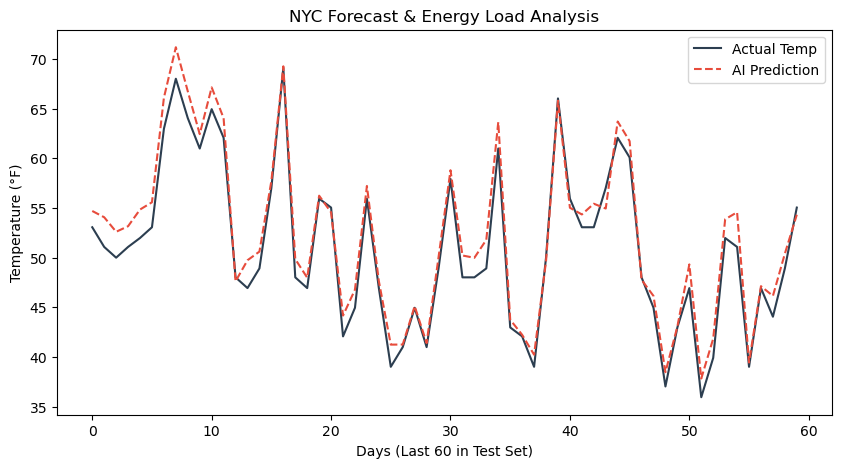

In [12]:
import pandas as pd  # Data manipulation and CSV handling
import numpy as np   # Mathematical operations (Sine/Cosine/Calculations)
import os            # Interacting with the computer's file system
from xgboost import XGBRegressor                    # Advanced Gradient Boosting ML model
from sklearn.model_selection import train_test_split # Splits data into training and testing
from sklearn.metrics import mean_absolute_error       # Measures accuracy of the model
import matplotlib.pyplot as plt                     # Creating charts and visualizations

# --- 1. CONFIGURATION ---
INPUT_FILE = 'Weather Data (US).csv'    # The raw 8GB NOAA dataset
PROCESSED_FILE = 'mid_atlantic_weather.csv' # The smaller, filtered output
BASE_TEMP = 65  # The industry standard "neutral" temperature for energy demand

# Mapping NOAA Station IDs to friendly names for business reporting
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

# --- 2. DATA EXTRACTION (Chunking the 8GB File) ---
def extract_data():
    """Scans the giant file for our specific stations without crashing the computer."""
    if not os.path.exists(PROCESSED_FILE):
        print(f"--- Scanning {INPUT_FILE}. This may take a few minutes... ---")
        chunks = []
        # 'chunksize' reads the file in small bites (100k lines) to prevent RAM overflow
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000, low_memory=False):
            # Check if the CSV uses 'ID' or 'STATION' as the column header
            col_name = 'ID' if 'ID' in chunk.columns else 'STATION'
            # Keep only the rows belonging to the stations in our STATION_MAP
            filtered = chunk[chunk[col_name].isin(STATION_MAP.keys())]
            chunks.append(filtered)
        
        # Merge all filtered bites into one CSV
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
        print(f"--- Success! Created {PROCESSED_FILE} ---")
    else:
        print(f"--- Using existing {PROCESSED_FILE} ---")

# --- 3. CLEANING & UNIT CONVERSION ---
def load_and_clean():
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE']) # Ensure dates are recognized as time
    
    id_col = 'ID' if 'ID' in df.columns else 'STATION'
    
    # Tenths of Celsius -> Fahrenheit conversion
    # NOAA stores 20.5°C as 205; we divide by 10 then convert to Fahrenheit
    for col in ['TMAX', 'TMIN']:
        if col in df.columns:
            df[col] = ((df[col] / 10) * 1.8) + 32
    return df, id_col

# --- 4. FEATURE ENGINEERING ---
def engineer_features(df, id_col):
    """Creates the clues the AI needs to make accurate predictions."""
    # Pivot so each station is its own column of daily temperatures
    pivot = df.pivot_table(index='DATE', columns=id_col, values='TMAX', aggfunc='mean')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # LAG FEATURES: Create a column for yesterday's temperature for every city
    # Knowing it was cold yesterday is a massive clue for today's temperature
    for loc in pivot.columns:
        pivot[f'{loc}_Yesterday'] = pivot[loc].shift(1)
    
    # SEASONAL SINUOSITY: Help the AI understand the 365-day cycle
    # Sin/Cos waves tell the AI that Jan 1st is close to Dec 31st
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return pivot.dropna() # Remove the first row which has no 'yesterday' data

# --- 5. UTILITY CALCULATIONS ---
def calculate_utility_metrics(actuals, guesses):
    """Calculates Degree Days to estimate heating and cooling demand."""
    energy_df = pd.DataFrame({'Actual': actuals, 'Predicted': guesses})
    
    # HDD (Heating Degree Days): Degrees BELOW 65°F (Need to run the heater)
    energy_df['HDD_AI'] = energy_df['Predicted'].apply(lambda x: max(0, BASE_TEMP - x))
    
    # CDD (Cooling Degree Days): Degrees ABOVE 65°F (Need to run the AC)
    energy_df['CDD_AI'] = energy_df['Predicted'].apply(lambda x: max(0, x - BASE_TEMP))
    return energy_df

# --- 6. EXECUTION ---
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        # 1. Process raw data
        extract_data()
        clean_df, station_col = load_and_clean()
        final_data = engineer_features(clean_df, station_col)
        
        # 2. ML Training (Targeting NYC Central Park)
        y = final_data['NYC_CentralPark'] # What we want to predict
        X = final_data.drop(columns=['NYC_CentralPark']) # Clues we use to predict
        
        # Chronological split (80% train, 20% test) - Do NOT shuffle weather data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        # Initialize the XGBoost model (Extreme Gradient Boosting)
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        # 3. Energy Load Analysis
        energy_metrics = calculate_utility_metrics(y_test, preds)
        
        # Output summary
        print(f"\n--- MODEL RESULTS ---")
        print(f"Avg Error: {mean_absolute_error(y_test, preds):.2f}°F")
        print(f"Total Predicted Heating Demand (HDD): {energy_metrics['HDD_AI'].sum():.1f}")

        # 4. Visualization of the Forecast
        plt.figure(figsize=(10, 5))
        plt.plot(y_test.values[-60:], label="Actual Temp", color='#2c3e50')
        plt.plot(preds[-60:], label="AI Prediction", color='#e74c3c', linestyle='--')
        plt.title("NYC Forecast & Energy Load Analysis")
        plt.xlabel("Days (Last 60 in Test Set)")
        plt.ylabel("Temperature (°F)")
        plt.legend()
        plt.show()
    else:
        print(f"Error: '{INPUT_FILE}' not found in the current directory.")

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- 1. Configuration & Filtering ---
FILE_NAME = 'Weather Data (US).csv'
# NYC Central Park Station ID (Standard NOAA ID)
NYC_STATION_ID = 'USW00094728' 

try:
    # Load data
    df = pd.read_csv(FILE_NAME)
    
    # Filter for Central Park
    # We check both 'STATION' and 'NAME' columns to be safe
    df_nyc = df[
        (df['STATION'] == NYC_STATION_ID) | 
        (df['NAME'].str.contains('CENTRAL PARK', case=False, na=False))
    ].copy()

    if df_nyc.empty:
        print("NYC Central Park data not found. Please check column names.")
    else:
        print(f"Successfully isolated {len(df_nyc)} rows for NYC Central Park.")

    # --- 2. Preprocessing ---
    df_nyc['DATE'] = pd.to_datetime(df_nyc['DATE'])
    df_nyc = df_nyc.sort_values('DATE')
    
    # Use 'TAVG' (Average Temp). If missing, calculate (TMAX + TMIN) / 2
    if 'TAVG' not in df_nyc.columns or df_nyc['TAVG'].isnull().all():
        df_nyc['TAVG'] = (df_nyc['TMAX'] + df_nyc['TMIN']) / 2
    
    df_nyc = df_nyc.dropna(subset=['TAVG'])
    target_data = df_nyc['TAVG'].values.reshape(-1, 1)

    # --- 3. RNN Pipeline ---
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(target_data)

    WINDOW_SIZE = 60
    X, y = [], []
    for i in range(WINDOW_SIZE, len(scaled_data)):
        X.append(scaled_data[i-WINDOW_SIZE:i, 0])
        y.append(scaled_data[i, 0])

    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Split (80/20)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Build Model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    # Plot Results
    preds = model.predict(X_test)
    preds = scaler.inverse_transform(preds)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    plt.figure(figsize=(12, 5))
    plt.plot(actual[-100:], label='Actual NYC Temp')
    plt.plot(preds[-100:], label='RNN Forecast')
    plt.title('Central Park Weather Prediction')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

Error: 'STATION'


Detected 'ID' column. Pivoting data into station columns...


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training CNN Weather Model (Input Features: 7) ---
Epoch 1/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 833.9738 
Epoch 2/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 15.2544
Epoch 3/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.8302
Epoch 4/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.0820
Epoch 5/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.1871
Epoch 6/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.5004
Epoch 7/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.2596
Epoch 8/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.9959
Epoch 9/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.9185
Epoch 10/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.8892
Epoch 11/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.8044
Epoch 12/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.7488
Epoch 13/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.7492
Epoch 14/40
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.75

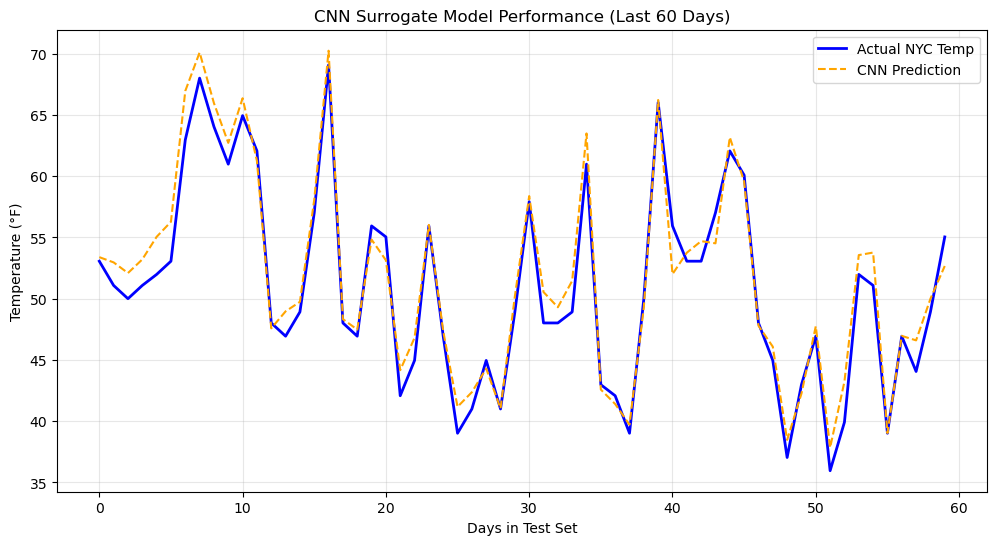

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Using TensorFlow/Keras for the CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, MaxPooling1D

# --- 1. DATA PREPARATION ---
PROCESSED_FILE = 'mid_atlantic_weather.csv'

def get_data():
    # Load data and clean column names
    df = pd.read_csv(PROCESSED_FILE)
    df.columns = df.columns.str.strip()
    
    # Convert DATE to datetime objects
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Based on your screenshot, the station column is named 'ID'
    if 'ID' in df.columns:
        print("Detected 'ID' column. Pivoting data into station columns...")
        
        # Convert TMAX from tenths of Celsius to Fahrenheit
        # Formula: (Celsius * 1.8) + 32. Since input is tenths, we divide by 10 first.
        df['TMAX'] = ((df['TMAX'] / 10) * 1.8) + 32
        
        # Pivot so each Station ID becomes its own column
        pivot = df.pivot_table(index='DATE', columns='ID', values='TMAX', aggfunc='mean')
    else:
        # Fallback if the data was already pivoted in a previous step
        print("ID column not found. Assuming data is already in Wide Format...")
        pivot = df.set_index('DATE')
    
    # Remove any days that have missing values across stations
    return pivot.dropna()

# --- 2. CNN ARCHITECTURE ---
def build_cnn(input_shape):
    model = Sequential([
        # Filters look for patterns across neighboring station temperatures
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(1) # Output: Predicted Temperature for NYC
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# --- 3. EXECUTION ---
if __name__ == "__main__":
    data = get_data()
    
    # Target Station: NYC Central Park
    target_station = 'USW00094728'
    
    if target_station not in data.columns:
        print(f"\nERROR: Target {target_station} not found in the pivoted data.")
        print(f"Available IDs: {data.columns.tolist()[:5]} ...")
    else:
        # y = The station we want to predict (NYC)
        # X = All other stations (the "features")
        y = data[target_station].values
        X = data.drop(columns=[target_station]).values
        
        # Standardize features (Crucial for Neural Networks)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Reshape for CNN: (Samples, Features, 1 Channel)
        X_reshaped = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))
        
        # Split into training and testing (Sequential split for time-series)
        X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, shuffle=False)
        
        # Build and Train
        model = build_cnn((X_train.shape[1], 1))
        print(f"\n--- Training CNN Weather Model (Input Features: {X_train.shape[1]}) ---")
        model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=1)
        
        # Predict
        preds = model.predict(X_test).flatten()
        
        print(f"\nFinal CNN MAE: {mean_absolute_error(y_test, preds):.2f}°F")

        # Visualization
        plt.figure(figsize=(12, 6))
        plt.plot(y_test[-60:], label="Actual NYC Temp", color='blue', linewidth=2)
        plt.plot(preds[-60:], label="CNN Prediction", color='orange', linestyle='--')
        plt.title("CNN Surrogate Model Performance (Last 60 Days)")
        plt.ylabel("Temperature (°F)")
        plt.xlabel("Days in Test Set")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib
import tensorflow as tf

# 1. PREVENT MEMORY & DISPLAY ERRORS
# Silence TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# Import matplotlib and set backend
import matplotlib.pyplot as plt
# Note: If 'TkAgg' causes an error on your system, comment out the line below
# matplotlib.use('TkAgg') 

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Hide specific deprecation warnings
tf.get_logger().setLevel('ERROR')

# --- CONFIGURATION ---
FILE_NAME = 'Weather Data (US).csv'
NYC_STATION_ID = 'USW00094728' 
WINDOW_SIZE = 60 # Using 60 days of history to predict the next day

def load_data_in_chunks(file_path):
    """Reads a massive CSV and standardizes column names before filtering."""
    print(f"Reading {file_path} in chunks to save memory...")
    chunks = []
    chunk_size = 100000 
    
    try:
        if not os.path.exists(file_path):
            print(f"Error: File '{file_path}' not found in the current directory.")
            return pd.DataFrame()
            
        for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
            # FIX: Standardize column names IMMEDIATELY (removes spaces and makes Uppercase)
            chunk.columns = chunk.columns.str.strip().str.upper()
            
            # Check if necessary columns exist
            if 'STATION' not in chunk.columns or 'NAME' not in chunk.columns:
                print(f"Error: Required columns 'STATION' or 'NAME' missing. Found: {list(chunk.columns)}")
                return pd.DataFrame()

            # Filter each chunk for NYC Central Park
            filtered_chunk = chunk[
                (chunk['STATION'] == NYC_STATION_ID) | 
                (chunk['NAME'].str.contains('CENTRAL PARK', case=False, na=False))
            ].copy()
            chunks.append(filtered_chunk)
        
        if not chunks:
            return pd.DataFrame()
            
        df_nyc = pd.concat(chunks, axis=0)
        return df_nyc
        
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return pd.DataFrame()

def main():
    # --- STEP 1: LOAD & FILTER ---
    df_nyc = load_data_in_chunks(FILE_NAME)

    if df_nyc.empty:
        print("No NYC Central Park data found. Ending script.")
        return

    print(f"Successfully loaded {len(df_nyc)} rows for NYC. Processing...")

    # --- STEP 2: PREPROCESSING ---
    # Convert DATE to datetime objects
    if 'DATE' in df_nyc.columns:
        df_nyc['DATE'] = pd.to_datetime(df_nyc['DATE'])
        df_nyc = df_nyc.sort_values('DATE')
    
    # Calculate Average Temp (TAVG) if missing, using Max and Min
    if 'TAVG' not in df_nyc.columns or df_nyc['TAVG'].isnull().all():
        if 'TMAX' in df_nyc.columns and 'TMIN' in df_nyc.columns:
            print("TAVG missing; calculating from TMAX and TMIN...")
            df_nyc['TAVG'] = (df_nyc['TMAX'] + df_nyc['TMIN']) / 2
        else:
            print("Error: Could not find TAVG, TMAX, or TMIN columns.")
            return
    
    df_nyc = df_nyc.dropna(subset=['TAVG'])
    data = df_nyc['TAVG'].values.reshape(-1, 1)

    # Scaling to range [0, 1] for LSTM efficiency
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # Create time-series windows
    X, y = [], []
    for i in range(WINDOW_SIZE, len(scaled_data)):
        X.append(scaled_data[i-WINDOW_SIZE:i, 0])
        y.append(scaled_data[i, 0])

    X, y = np.array(X), np.array(y)
    # Reshape for LSTM: [samples, time_steps, features]
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Split into Train (80%) and Test (20%)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # --- STEP 3: BUILD THE RNN (LSTM) ---
    print("Initializing LSTM model...")
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Early stopping prevents overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=3)

    print("Beginning training...")
    model.fit(
        X_train, y_train, 
        epochs=15, 
        batch_size=32, 
        validation_split=0.1, 
        callbacks=[early_stop],
        verbose=1
    )

    # --- STEP 4: PREDICT & VISUALIZE ---
    print("Generating predictions...")
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    print("Generating plot...")
    plt.figure(figsize=(14, 7))
    # Plotting only the last year (365 days) for better visibility
    plt.plot(actual[-365:], color='black', label='Observed Temp (NYC)')
    plt.plot(predictions[-365:], color='orange', label='RNN Prediction', linestyle='--')
    plt.title('NYC Central Park Temperature Forecast')
    plt.xlabel('Days (Test Subset)')
    plt.ylabel('Temperature')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    plt.show()

if __name__ == "__main__":
    main()

Reading Weather Data (US).csv in chunks to save memory...
Error: Required columns 'STATION' or 'NAME' missing. Found: ['ID', 'DATE', 'TMAX', 'TMIN', 'EVAP', 'PRCP', 'LATITUDE', 'LONGITUDE', 'ELEVATION']
No NYC Central Park data found. Ending script.


Reading Weather Data (US).csv in chunks...
Successfully loaded 10593 rows for NYC Central Park.
Training LSTM model on the first 80% of data...
Epoch 1/15


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0159
Epoch 2/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0107
Epoch 3/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0098
Epoch 4/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0094
Epoch 5/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.0088
Epoch 6/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0083
Epoch 7/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.0077
Epoch 8/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0074
Epoch 9/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0070
Epoch 10/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0068
Epoch 11/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0067
Epoch 12/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0066
Epoch 13/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0065
Epoch 14/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0064
Epoch 15/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 2

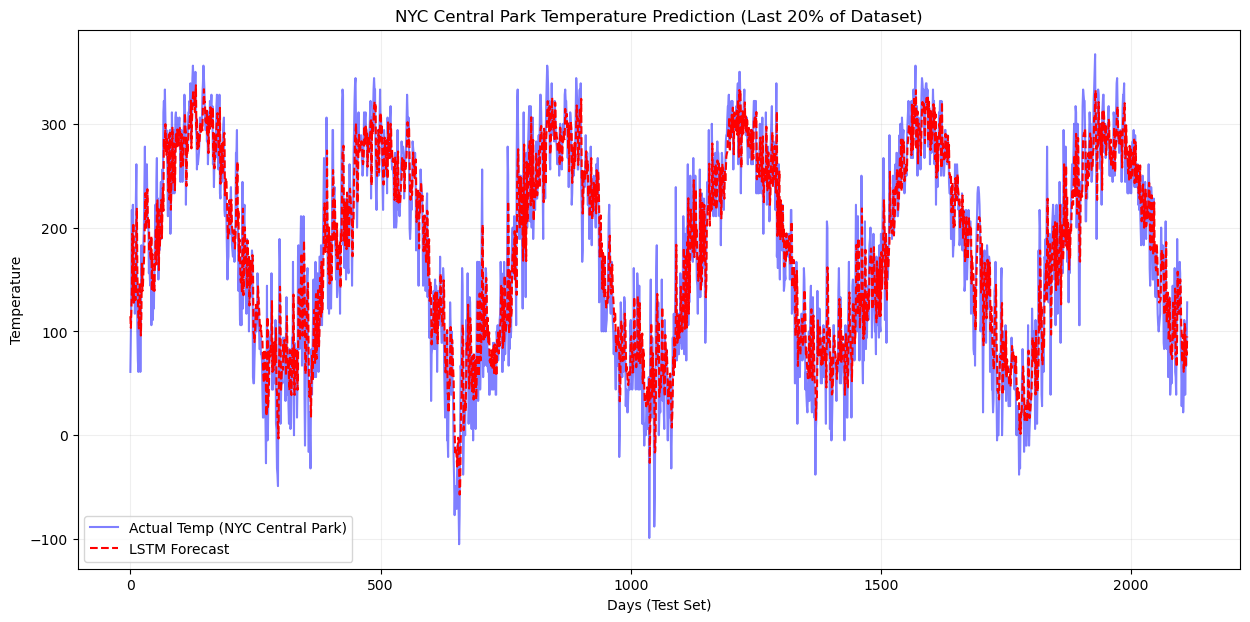

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import os

# Suppress TensorFlow logging for a cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def create_sequences(data, seq_length):
    """Creates sliding window sequences for the RNN."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

def main():
    # 1. SETTINGS
    file_path = 'Weather Data (US).csv' 
    nyc_id = 'USW00094728'  # Station ID for NYC Central Park
    
    # Based on your error message, these are the exact column names:
    station_col = 'ID'
    date_col = 'DATE'
    temp_col = 'TMAX'
    
    # 2. MEMORY-EFFICIENT LOADING (Chunking)
    print(f"Reading {file_path} in chunks...")
    chunk_list = []
    try:
        # We only load the columns we need to save RAM
        for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False, 
                                 usecols=[station_col, date_col, temp_col]):
            
            # Filter for NYC station immediately
            filtered_chunk = chunk[chunk[station_col].astype(str).str.strip() == nyc_id]
            chunk_list.append(filtered_chunk)
        
        df = pd.concat(chunk_list)
        if df.empty:
            print(f"No data found for ID: {nyc_id}. Please check the ID in the CSV.")
            return
        print(f"Successfully loaded {len(df)} rows for NYC Central Park.")
        
    except FileNotFoundError:
        print(f"Error: {file_path} not found.")
        return
    except ValueError as e:
        print(f"Column Error: {e}")
        return

    # 3. DATA PREPARATION
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).dropna(subset=[temp_col])
    
    # Convert temperature to float (handling any non-numeric strings)
    data = pd.to_numeric(df[temp_col], errors='coerce').dropna().values.reshape(-1, 1)
    data = data.astype('float32')

    # Scaling (LSTM performs best with values between 0 and 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # 4. WINDOWING
    seq_length = 30  # Use previous 30 days to predict the next
    X, y = create_sequences(scaled_data, seq_length)

    # 5. SPLIT (80% Train, 20% Test)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Reshape to [samples, time steps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # 6. LSTM MODEL ARCHITECTURE
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(units=50),
        Dropout(0.2),
        Dense(units=1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # 7. TRAINING
    print("Training LSTM model on the first 80% of data...")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)

    # 8. PREDICTIONS (Predicting the final 20%)
    print("Predicting the last 20%...")
    predictions = model.predict(X_test)
    
    # Inverse transform to get actual temperatures back
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # 9. VISUALIZATION
    plt.figure(figsize=(15, 7))
    plt.plot(actual, color='blue', label='Actual Temp (NYC Central Park)', alpha=0.5)
    plt.plot(predictions, color='red', label='LSTM Forecast', linestyle='--')
    plt.title('NYC Central Park Temperature Prediction (Last 20% of Dataset)')
    plt.xlabel('Days (Test Set)')
    plt.ylabel('Temperature')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
LSTM

Reading Weather Data (US).csv in chunks to filter for NYC data...

      DATASET VERIFICATION
Total days of data found: 10593
Training set size (80%): 8450 days
Test set size (20%):     2113 days

Training LSTM model on the training set...
Epoch 1/15


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


265/265 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.0176
Epoch 2/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0102
Epoch 3/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.0097
Epoch 4/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0092
Epoch 5/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0087
Epoch 6/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0081
Epoch 7/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0077
Epoch 8/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0072
Epoch 9/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0070
Epoch 10/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0068
Epoch 11/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0067
Epoch 12/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0065
Epoch 13/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0065
Epoch 14/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0064
Epoch 15/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms

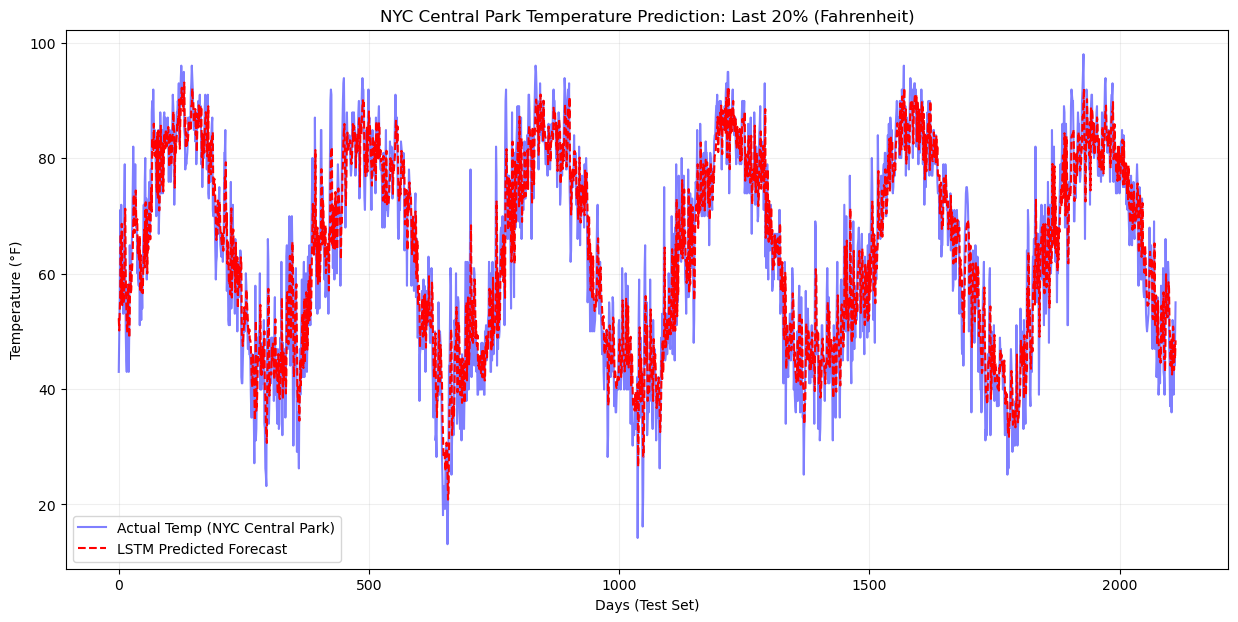

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout  # Changed GRU to LSTM
import os

# Suppress TensorFlow logging for a cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def create_sequences(data, seq_length):
    """Creates sliding window sequences for the LSTM."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

def main():
    # --- 1. CONFIGURATION ---
    file_path = 'Weather Data (US).csv' 
    nyc_id = 'USW00094728'  # Station ID for NYC Central Park
    station_col = 'ID'
    date_col = 'DATE'
    temp_col = 'TMAX'
    seq_length = 30         # Uses the last 30 days to predict the next day
    
    # --- 2. MEMORY-EFFICIENT LOADING (Chunking) ---
    print(f"Reading {file_path} in chunks to filter for NYC data...")
    chunk_list = []
    try:
        # Load only necessary columns to save RAM
        for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False, 
                                 usecols=[station_col, date_col, temp_col]):
            
            # Filter for NYC Central Park records
            filtered_chunk = chunk[chunk[station_col].astype(str).str.strip() == nyc_id]
            chunk_list.append(filtered_chunk)
        
        df = pd.concat(chunk_list)
        if df.empty:
            print(f"Error: No data found for station ID {nyc_id}.")
            return
            
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    # --- 3. DATA PRE-PROCESSING & FAHRENHEIT CONVERSION ---
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)
    
    # Convert from raw tenths of Celsius to Fahrenheit
    # Formula: (Raw * 0.1 * 1.8) + 32  =>  Raw * 0.18 + 32
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[temp_col] = (df[temp_col] * 0.18) + 32
    
    # Remove any rows with missing temperatures
    data = df[[temp_col]].dropna().values.astype('float32')
    total_days = len(data)

    # Scale the data between 0 and 1 (Essential for LSTM performance)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # Generate sliding window sequences
    X, y = create_sequences(scaled_data, seq_length)

    # --- 4. CHRONOLOGICAL DATA SPLIT (80/20) ---
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # --- DATASET VERIFICATION SUMMARY ---
    print("\n" + "="*35)
    print("      DATASET VERIFICATION")
    print("="*35)
    print(f"Total days of data found: {total_days}")
    print(f"Training set size (80%): {len(X_train)} days")
    print(f"Test set size (20%):     {len(X_test)} days")
    print("="*35)

    # Reshape for LSTM: [samples, time steps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # --- 5. BUILD LSTM MODEL ---
    model = Sequential([
        LSTM(units=64, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(units=64),
        Dropout(0.2),
        Dense(units=1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # --- 6. TRAINING ---
    print("\nTraining LSTM model on the training set...")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)

    # --- 7. PREDICTIONS & EVALUATION ---
    print("\nGenerating predictions for the test set...")
    predictions_scaled = model.predict(X_test)
    
    # Invert scaling to get Fahrenheit back
    predictions = scaler.inverse_transform(predictions_scaled)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate Accuracy Metrics
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    r2 = r2_score(actual, predictions)

    print("\n" + "="*35)
    print("      ACCURACY (FAHRENHEIT)")
    print("="*35)
    print(f"Mean Absolute Error (MAE): {mae:.2f} °F")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °F")
    print(f"R-squared Score (R2): {r2:.4f}")
    print("="*35)

    # --- 8. VISUALIZATION ---
    plt.figure(figsize=(15, 7))
    plt.plot(actual, color='blue', label='Actual Temp (NYC Central Park)', alpha=0.5)
    plt.plot(predictions, color='red', label='LSTM Predicted Forecast', linestyle='--')
    plt.title('NYC Central Park Temperature Prediction: Last 20% (Fahrenheit)')
    plt.xlabel('Days (Test Set)')
    plt.ylabel('Temperature (°F)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
GRU

Reading Weather Data (US).csv in chunks to filter for NYC data...

--- Dataset Summary ---
Total days of data found: 10593
Days used for Training (80%): 8450
Days used for Testing (20%):  2113
-------------------------

Training GRU model...
Epoch 1/15


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


265/265 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0177
Epoch 2/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0088
Epoch 3/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0078
Epoch 4/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0074
Epoch 5/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0073
Epoch 6/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0069
Epoch 7/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0068
Epoch 8/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0068
Epoch 9/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0066
Epoch 10/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0064
Epoch 11/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0065
Epoch 12/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0063
Epoch 13/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0062
Epoch 14/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0062
Epoch 15/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/s

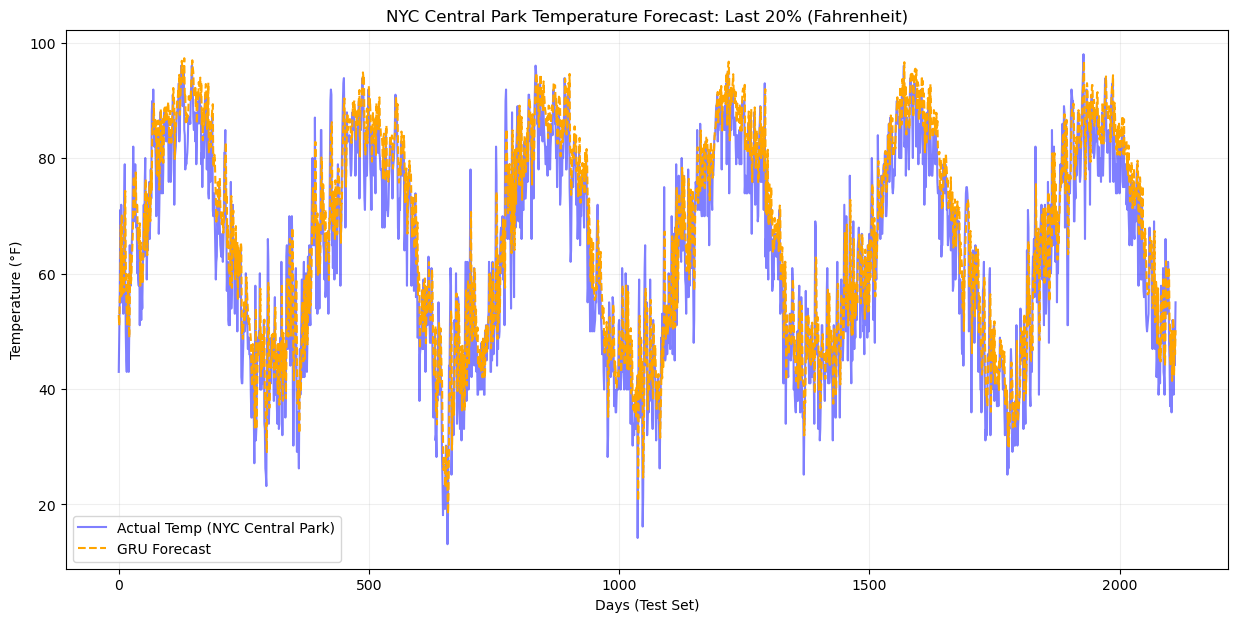

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import os

# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def create_sequences(data, seq_length):
    """Creates sliding window sequences for the GRU."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

def main():
    # --- 1. CONFIGURATION ---
    file_path = 'Weather Data (US).csv' 
    nyc_id = 'USW00094728'  # NYC Central Park ID
    station_col = 'ID'
    date_col = 'DATE'
    temp_col = 'TMAX'
    seq_length = 30         # 30-day lookback
    
    # --- 2. MEMORY-EFFICIENT DATA LOADING ---
    print(f"Reading {file_path} in chunks to filter for NYC data...")
    chunk_list = []
    try:
        for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False, 
                                 usecols=[station_col, date_col, temp_col]):
            filtered_chunk = chunk[chunk[station_col].astype(str).str.strip() == nyc_id]
            chunk_list.append(filtered_chunk)
        
        df = pd.concat(chunk_list)
        if df.empty:
            print(f"Error: No data found for station ID {nyc_id}.")
            return
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    # --- 3. DATA PRE-PROCESSING & FAHRENHEIT CONVERSION ---
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)
    
    # Clean and convert: (Raw Tenths of Celsius * 0.1) * 1.8 + 32 = Fahrenheit
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[temp_col] = (df[temp_col] * 0.18) + 32  # Conversion formula
    
    data = df[[temp_col]].dropna().values.astype('float32')
    total_days = len(data)

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # Generate sequences
    X, y = create_sequences(scaled_data, seq_length)

    # --- 4. CHRONOLOGICAL DATA SPLIT (80/20) ---
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print("\n--- Dataset Summary ---")
    print(f"Total days of data found: {total_days}")
    print(f"Days used for Training (80%): {len(X_train)}")
    print(f"Days used for Testing (20%):  {len(X_test)}")
    print("-" * 25)

    # Reshape for GRU
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # --- 5. BUILD & TRAIN GRU MODEL ---
    model = Sequential([
        GRU(units=64, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        GRU(units=64),
        Dropout(0.2),
        Dense(units=1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print("\nTraining GRU model...")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)

    # --- 6. PREDICTIONS & EVALUATION ---
    predictions_scaled = model.predict(X_test)
    
    # Invert scaling back to Fahrenheit
    predictions = scaler.inverse_transform(predictions_scaled)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate Accuracy Metrics
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    r2 = r2_score(actual, predictions)

    print("\n" + "="*35)
    print(f"      ACCURACY (FAHRENHEIT)")
    print("="*35)
    print(f"Mean Absolute Error (MAE): {mae:.2f} °F")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °F")
    print(f"R-squared Score (R2): {r2:.4f}")
    print("="*35)

    # --- 7. VISUALIZATION ---
    plt.figure(figsize=(15, 7))
    plt.plot(actual, color='blue', label='Actual Temp (NYC Central Park)', alpha=0.5)
    plt.plot(predictions, color='orange', label='GRU Forecast', linestyle='--')
    plt.title('NYC Central Park Temperature Forecast: Last 20% (Fahrenheit)')
    plt.xlabel('Days (Test Set)')
    plt.ylabel('Temperature (°F)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
Simple RNN

Loading NYC data for Simple RNN Baseline...
Training Simple RNN...
Epoch 1/12


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0938
Epoch 2/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0192
Epoch 3/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0131
Epoch 4/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0111
Epoch 5/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0095
Epoch 6/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0089
Epoch 7/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0083
Epoch 8/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0082
Epoch 9/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0078
Epoch 10/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0074
Epoch 11/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0072
Epoch 12/12
265/265 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0069
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

   SIMPLE RNN RESULTS
Mean Absolute Error (MAE): 5.68 °F
Root Mean Squared Error (RMSE): 7.32 °F
R-squared Score (R2): 0.8268


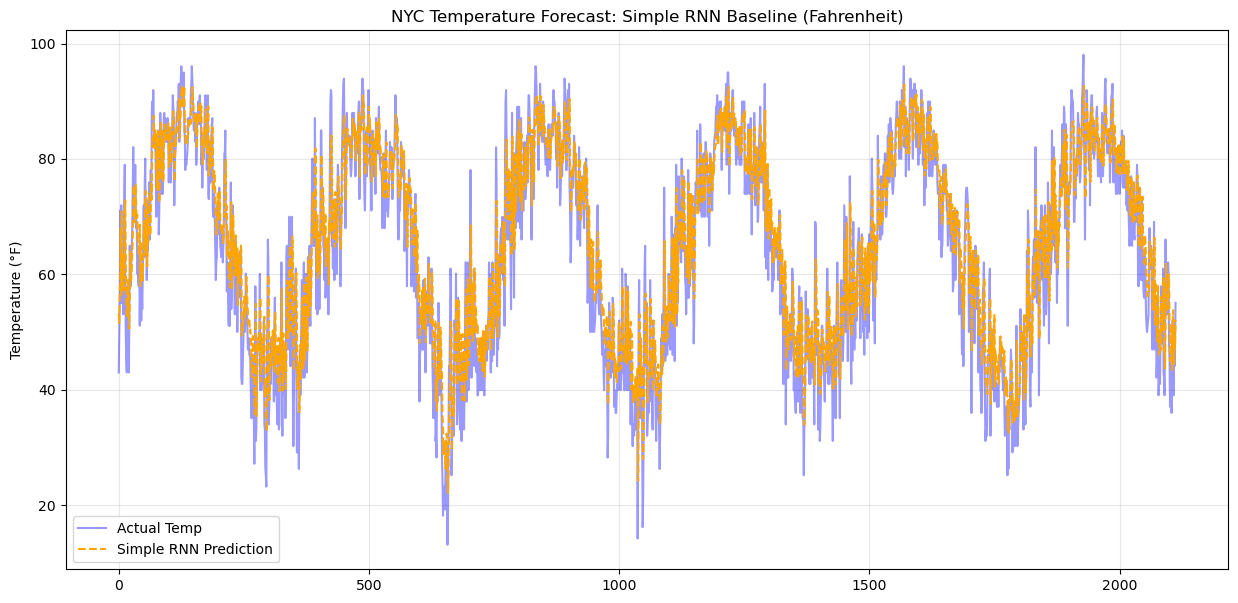

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
import os

# --- 1. SETTINGS ---
file_path = 'Weather Data (US).csv' 
nyc_id = 'USW00094728' 
temp_col = 'TMAX'
seq_length = 30  

# --- 2. DATA LOADING & PRE-PROCESSING ---
print("Loading NYC data for Simple RNN Baseline...")
chunks = pd.read_csv(file_path, chunksize=100000, low_memory=False, usecols=['ID', 'DATE', temp_col])
df = pd.concat([c[c['ID'].astype(str).str.strip() == nyc_id] for c in chunks])

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# Convert to Fahrenheit
df[temp_col] = (pd.to_numeric(df[temp_col], errors='coerce') * 0.18) + 32
data = df[[temp_col]].dropna().values.astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_length)

# 80/20 Chronological Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# --- 3. BUILD SIMPLE RNN MODEL ---
# Using 12 epochs to match your previous LSTM/GRU run logic
model = Sequential([
    SimpleRNN(units=64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    SimpleRNN(units=64),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

print("Training Simple RNN...")
model.fit(X_train, y_train, epochs=12, batch_size=32, verbose=1)

# --- 4. EVALUATION ---
preds_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(preds_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
r2 = r2_score(actual, predictions)

# --- 5. RESULTS OUTPUT ---
print("\n" + "="*35)
print(f"   SIMPLE RNN RESULTS")
print("="*35)
print(f"Mean Absolute Error (MAE): {mae:.2f} °F")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °F")
print(f"R-squared Score (R2): {r2:.4f}")
print("="*35)

# --- 6. PLOTTING ---
plt.figure(figsize=(15, 7))
plt.plot(actual, color='blue', label='Actual Temp', alpha=0.4)
plt.plot(predictions, color='orange', label='Simple RNN Prediction', linestyle='--')
plt.title('NYC Temperature Forecast: Simple RNN Baseline (Fahrenheit)')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
import os

# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def create_sequences(data, seq_length):
    """Creates sliding window sequences for the models."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

def build_model(model_type, seq_length):
    """Factory function to build the requested architecture."""
    model = Sequential()
    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units=64, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(Dropout(0.2))
        model.add(SimpleRNN(units=64))
    elif model_type == 'LSTM':
        model.add(LSTM(units=64, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(Dropout(0.2))
        model.add(LSTM(units=64))
    elif model_type == 'GRU':
        model.add(GRU(units=64, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(Dropout(0.2))
        model.add(GRU(units=64))
    
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def main():
    # --- 1. SETTINGS ---
    file_path = 'Weather Data (US).csv' 
    nyc_id = 'USW00094728' 
    temp_col = 'TMAX'
    seq_length = 30  
    
    # --- 2. DATA PREPARATION ---
    print(f"Loading NYC data and converting to Fahrenheit...")
    chunks = pd.read_csv(file_path, chunksize=100000, low_memory=False, usecols=['ID', 'DATE', temp_col])
    df = pd.concat([c[c['ID'].astype(str).str.strip() == nyc_id] for c in chunks])
    
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')
    
    # Unit Conversion: (Raw * 0.18) + 32 = Fahrenheit
    df[temp_col] = (pd.to_numeric(df[temp_col], errors='coerce') * 0.18) + 32
    data = df[[temp_col]].dropna().values.astype('float32')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    X, y = create_sequences(scaled_data, seq_length)

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # --- 3. TRAINING & PLOTTING ---
    plt.figure(figsize=(15, 8))
    actual_f = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # ACTUAL: Solid Black (The Ground Truth)
    plt.plot(actual_f, color='#000000', label='Actual Temp', alpha=0.5, linewidth=1.5)

    # UPDATED COLOR PALETTE
    # Simple RNN = Bright Orange
    # LSTM = Sky Blue
    # GRU = Deep Red
    colors = {'SimpleRNN': '#E67E22', 'LSTM': '#3498DB', 'GRU': '#E74C3C'}
    styles = {'SimpleRNN': ':', 'LSTM': '--', 'GRU': '-.'}

    for arch in ['SimpleRNN', 'LSTM', 'GRU']:
        print(f"Training {arch}...")
        model = build_model(arch, seq_length)
        model.fit(X_train, y_train, epochs=12, batch_size=32, verbose=0)
        
        preds_f = scaler.inverse_transform(model.predict(X_test))
        mae = mean_absolute_error(actual_f, preds_f)
        
        plt.plot(preds_f, color=colors[arch], label=f'{arch} (MAE: {mae:.2f}°F)', 
                 linestyle=styles[arch], linewidth=2)

    # --- 4. FORMATTING FOR THE REPORT ---
    plt.title('Performance Comparison: RNN vs. LSTM vs. GRU (NYC)', fontsize=14, fontweight='bold')
    plt.xlabel('Days (Test Set)', fontsize=12)
    plt.ylabel('Temperature (°F)', fontsize=12)
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.4)
    
    # Optional: Zoom in on the first 365 days to see daily variance better
    # plt.xlim(0, 365) 
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Loading NYC data and converting to Fahrenheit...


Preparing data...
Testing SimpleRNN...


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Testing LSTM...


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Testing GRU...


C:\Users\harol\miniconda3\envs\CMSC486\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


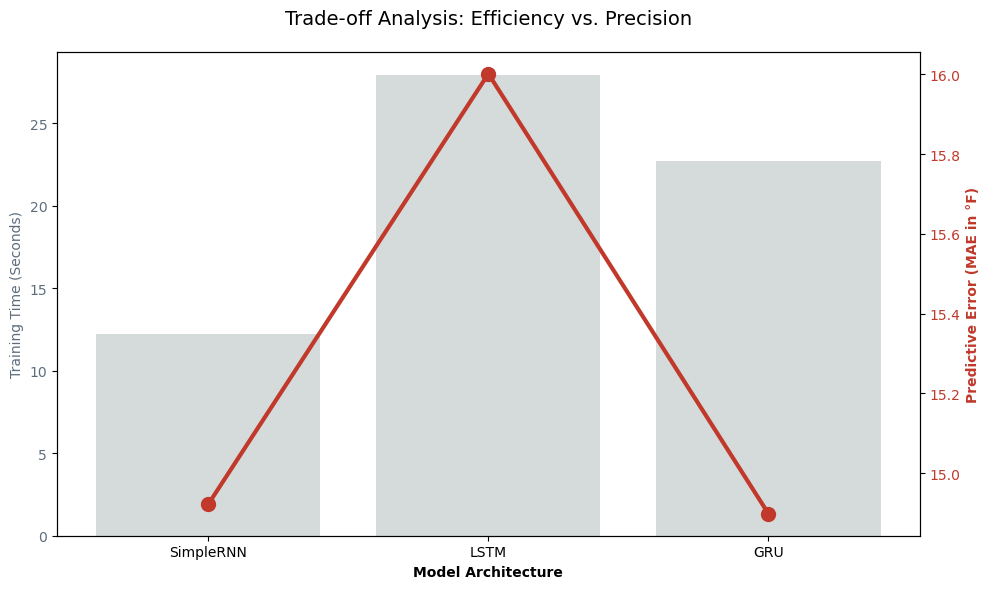

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- HELPER FUNCTIONS ---
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

def build_model(model_type, seq_length):
    model = Sequential()
    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units=64, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(SimpleRNN(units=64))
    elif model_type == 'LSTM':
        model.add(LSTM(units=64, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(LSTM(units=64))
    elif model_type == 'GRU':
        model.add(GRU(units=64, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(GRU(units=64))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def main():
    # --- DATA SETUP ---
    file_path = 'Weather Data (US).csv'
    nyc_id = 'USW00094728'
    temp_col = 'TMAX'
    seq_length = 30

    print("Preparing data...")
    chunks = pd.read_csv(file_path, chunksize=100000, usecols=['ID', 'DATE', temp_col])
    df = pd.concat([c[c['ID'].astype(str).str.strip() == nyc_id] for c in chunks])
    df[temp_col] = (pd.to_numeric(df[temp_col], errors='coerce') * 0.18) + 32
    data = df[[temp_col]].dropna().values.astype('float32')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    X, y = create_sequences(scaled_data, seq_length)
    
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # --- COMPARATIVE TESTING ---
    architectures = ['SimpleRNN', 'LSTM', 'GRU']
    mae_results = []
    time_results = []

    for arch in architectures:
        print(f"Testing {arch}...")
        model = build_model(arch, seq_length)
        
        # Track time
        start_time = time.time()
        model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)
        end_time = time.time()
        
        # Track error
        preds = scaler.inverse_transform(model.predict(X_test))
        actual = scaler.inverse_transform(y_test.reshape(-1, 1))
        mae = mean_absolute_error(actual, preds)
        
        mae_results.append(mae)
        time_results.append(end_time - start_time)

    # --- THE DUAL-AXIS GRAPH ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar Chart: Efficiency (Training Time)
    ax1.set_xlabel('Model Architecture', fontweight='bold')
    ax1.set_ylabel('Training Time (Seconds)', color='#5D6D7E')
    ax1.bar(architectures, time_results, color='#D5DBDB', label='Training Latency')
    ax1.tick_params(axis='y', labelcolor='#5D6D7E')

    # Line Chart: Precision (MAE)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Predictive Error (MAE in °F)', color='#C0392B', fontweight='bold')
    ax2.plot(architectures, mae_results, color='#C0392B', marker='o', linewidth=3, markersize=10, label='MAE (Error)')
    ax2.tick_params(axis='y', labelcolor='#C0392B')

    plt.title('Trade-off Analysis: Efficiency vs. Precision', fontsize=14, pad=20)
    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()